1) IMPORTAR LIBRERIAS

In [1]:
import sys
print(sys.executable)

c:\Users\alfon\anaconda3\envs\datos\python.exe


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2)Configuración de visualización##

In [7]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 3) Cargamos ficheros ##

In [48]:
df_student_mat = pd.read_csv("C:/Users/alfon/Desktop/Master/Proyecto final/Datos en bruto/student-mat.csv", sep=";", engine="python")

df_world_education = pd.read_csv("C:/Users/alfon/Desktop/Master/Proyecto final/Datos en bruto/world_education_system_dataset.csv")

4) # Comprobacion de carga

In [49]:
print("student_mat CSV cargado correctamente:")
print(df_student_mat.shape)
print(df_student_mat.head())

print("world_education CSV cargado correctamente:")
print(df_world_education.shape)
print(df_world_education.head())

student_mat CSV cargado correctamente:
(395, 33)
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
world_education CSV cargado correctamen

#5) Limpieza de datos student-mat

In [53]:
print("\n--- LIMPIEZA df_student-mat ---")

df_clean = df_student_mat.copy()

# 1. Información general
print("Información del dataset:")
print(df_clean.info())

# 2. Nulos
print("\nValores nulos por columna:")
print(df_clean.isnull().sum())

# 3. Duplicados
print("\nDuplicados antes de limpiar:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Duplicados después de limpiar:", df_clean.duplicated().sum())

# 4. Normalizar nombres
df_clean.columns = df_clean.columns.str.lower().str.replace(" ", "_")

# 5. Convertir SOLO columnas numéricas
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print("\nDataset limpio listo para análisis.")
df_clean.head()


--- LIMPIEZA df_student-mat ---
Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null

,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,famrel,freetime,goout,dalc,walc,health,absences,g1,g2,g3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


#6) Limpieza de datos world education

In [54]:
print("\n--- LIMPIEZA df_world education---")
df_world_clean = df_world_education.copy()

# 1. Información general
print("Información del dataset:")
print(df_world_clean.info())

# 2. Nulos
print("\nValores nulos por columna:")
print(df_world_clean.isnull().sum())

# 3. Duplicados
print("\nDuplicados antes de limpiar:", df_world_clean.duplicated().sum())
df_world_clean = df_world_clean.drop_duplicates()
print("Duplicados después de limpiar:", df_world_clean.duplicated().sum())

# 4. Normalizar nombres
df_world_clean.columns = df_world_clean.columns.str.lower().str.replace(" ", "_")

# 5. Convertir SOLO columnas numéricas
numeric_cols = df_world_clean.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    df_world_clean[col] = pd.to_numeric(df_world_clean[col], errors="coerce")

print("\nDataset world_education limpio y listo para análisis.")
df_world_clean.head()


--- LIMPIEZA df_world education---
Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Record_ID                    45000 non-null  int64  
 1   Year                         45000 non-null  int64  
 2   Country                      45000 non-null  str    
 3   Continent                    45000 non-null  str    
 4   Education_Level              45000 non-null  str    
 5   Institution_Type             45000 non-null  str    
 6   Student_ID                   45000 non-null  str    
 7   Age                          45000 non-null  int64  
 8   Gender                       45000 non-null  str    
 9   Area                         45000 non-null  str    
 10  Enrollment_Status            45000 non-null  str    
 11  Attendance_Rate              45000 non-null  float64
 12  Exam_Score              

,record_id,year,country,continent,education_level,institution_type,student_id,age,gender,area,...,literacy_rate,teacher_student_ratio,education_expenditure_gdp,internet_access,digital_learning_index,stem_enrollment,scholarship_received,employment_after_graduation,satisfaction_index,education_rank
0,1,2019,Finland,Europe,Primary,Public,S100001,11,Male,Rural,...,76.9,10,3.06,50.1,72.1,48.7,No,NaN,61.0,72
1,2,2020,China,Asia,Primary,Public,S100002,12,Male,Urban,...,84.1,35,2.76,64.9,38.7,70.3,Yes,NaN,77.6,93
2,3,2022,Japan,Asia,Primary,Private,S100003,12,Male,Rural,...,86.8,32,8.12,77.1,72.6,25.3,Yes,NaN,58.2,98
3,4,2018,Japan,Asia,Secondary,Private,S100004,15,Female,Rural,...,72.6,30,5.50,92.5,75.0,23.6,Yes,NaN,62.3,144
4,5,2020,Japan,Asia,Higher Education,Private,S100005,30,Female,Urban,...,62.5,22,6.08,65.4,47.6,48.2,Yes,79.5,55.7,138


# 7)Deteccion outliers

In [55]:
outliers_iqr = {}

for col in numeric_cols:
    Q1 = df_world_clean[col].quantile(0.25)
    Q3 = df_world_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_world_clean[(df_world_clean[col] < lower) | (df_world_clean[col] > upper)]
    outliers_iqr[col] = len(outliers)

outliers_iqr

{'record_id': 0,
 'year': 0,
 'age': 0,
 'attendance_rate': 0,
 'exam_score': 166,
 'graduation_rate': 0,
 'dropout_rate': 0,
 'literacy_rate': 0,
 'teacher_student_ratio': 0,
 'education_expenditure_gdp': 0,
 'internet_access': 0,
 'digital_learning_index': 0,
 'stem_enrollment': 0,
 'employment_after_graduation': 0,
 'satisfaction_index': 0,
 'education_rank': 0}

# 8) Unimos datasets con contac ya que no tienen columnas iguales

In [56]:
print("\n--- UNIÓN DE DATASETS ---")

df_final = pd.concat([df_clean, df_world_clean], axis=0, ignore_index=True)

print("Dataset final unido correctamente:")
print(df_final.shape)
df_final.head()


--- UNIÓN DE DATASETS ---
Dataset final unido correctamente:
(45395, 57)


,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,literacy_rate,teacher_student_ratio,education_expenditure_gdp,internet_access,digital_learning_index,stem_enrollment,scholarship_received,employment_after_graduation,satisfaction_index,education_rank
0,GP,F,18,U,GT3,A,4.0,4.0,at_home,teacher,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GP,F,17,U,GT3,T,1.0,1.0,at_home,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GP,F,15,U,LE3,T,1.0,1.0,at_home,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GP,F,15,U,GT3,T,4.0,2.0,health,services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GP,F,16,U,GT3,T,3.0,3.0,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
import openpyxl

In [61]:
df_final.to_excel(
    "C:/Users/alfon/Desktop/Master/Proyecto final/dataset_unido.xlsx",
    index=False,
    engine="xlsxwriter"
)

In [62]:
import os
os.path.exists(r"C:/Users/alfon/Desktop/Master/Proyecto final/dataset_unido.xlsx")

True

# 9) Información general del dataset final

In [63]:
print("Información general del dataset final:")
print(df_final.info())

Información general del dataset final:
<class 'pandas.DataFrame'>
RangeIndex: 45395 entries, 0 to 45394
Data columns (total 57 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   school                       395 non-null    str    
 1   sex                          395 non-null    str    
 2   age                          45395 non-null  int64  
 3   address                      395 non-null    str    
 4   famsize                      395 non-null    str    
 5   pstatus                      395 non-null    str    
 6   medu                         395 non-null    float64
 7   fedu                         395 non-null    float64
 8   mjob                         395 non-null    str    
 9   fjob                         395 non-null    str    
 10  reason                       395 non-null    str    
 11  guardian                     395 non-null    str    
 12  traveltime                   395 non-null    f

# 10) Nulos por columna

In [64]:
print("\nNulos por columna:")
print(df_final.isnull().sum().sort_values(ascending=False))


Nulos por columna:
school                         45000
goout                          45000
nursery                        45000
higher                         45000
internet                       45000
romantic                       45000
famrel                         45000
freetime                       45000
dalc                           45000
paid                           45000
walc                           45000
sex                            45000
absences                       45000
g1                             45000
g2                             45000
g3                             45000
activities                     45000
health                         45000
famsup                         45000
mjob                           45000
schoolsup                      45000
famsize                        45000
pstatus                        45000
medu                           45000
fedu                           45000
address                        45000
fjob              

# 11) Estadísticas descriptivas

In [65]:
print("\nDescripción estadística:")
df_final.describe(include='all')


Descripción estadística:


,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,literacy_rate,teacher_student_ratio,education_expenditure_gdp,internet_access,digital_learning_index,stem_enrollment,scholarship_received,employment_after_graduation,satisfaction_index,education_rank
count,395,395,45395.000000,395,395,395,395.000000,395.000000,395,395,...,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000,15075.000000,45000.000000,45000.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN,NaN,NaN
freq,349,208,NaN,307,281,354,NaN,NaN,141,217,...,NaN,NaN,NaN,NaN,NaN,NaN,22644,NaN,NaN,NaN
mean,NaN,NaN,16.227734,NaN,NaN,NaN,2.749367,2.521519,NaN,NaN,...,80.066802,25.077867,5.487984,67.472653,64.803964,44.948669,NaN,69.133373,74.998236,75.743333
std,NaN,NaN,6.666274,NaN,NaN,NaN,1.094735,1.088201,NaN,NaN,...,11.553449,8.950805,1.734883,18.742318,20.207127,17.343823,NaN,16.738844,14.454463,43.338539
min,NaN,NaN,6.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,60.000000,10.000000,2.500000,35.000000,30.000000,15.000000,NaN,40.000000,50.000000,1.000000
25%,NaN,NaN,11.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,...,70.100000,17.000000,3.980000,51.300000,47.300000,29.900000,NaN,54.500000,62.500000,38.000000
50%,NaN,NaN,16.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,...,80.100000,25.000000,5.490000,67.500000,64.600000,44.900000,NaN,69.300000,75.000000,76.000000
75%,NaN,NaN,21.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,...,90.100000,33.000000,6.990000,83.700000,82.300000,60.100000,NaN,83.600000,87.500000,113.000000


In [68]:
print("\nFrecuencias - Variables categóricas:")
for col in ['age', 'education_level', 'fjinstitution_typeob', 'gender', 'country']:
    if col in df_final.columns:
        print(f"\n{col.upper()}:")
        print(df_final[col].value_counts())


Frecuencias - Variables categóricas:

AGE:
age
18    3760
17    2647
16    2616
15    2610
14    2481
13    2456
10    2179
7     2169
11    2146
12    2098
6     2098
8     2087
9     2080
25    1228
24    1196
30    1187
27    1183
28    1172
22    1168
21    1160
29    1152
19    1143
23    1142
20    1138
26    1099
Name: count, dtype: int64

EDUCATION_LEVEL:
education_level
Higher Education    15075
Secondary           15068
Primary             14857
Name: count, dtype: int64

GENDER:
gender
Female    22503
Male      22497
Name: count, dtype: int64

COUNTRY:
country
Turkey            1906
South Korea       1855
India             1835
Sweden            1829
Nigeria           1829
Italy             1820
Netherlands       1816
UAE               1813
Argentina         1809
Mexico            1805
Canada            1804
United Kingdom    1800
Germany           1793
Japan             1791
Finland           1787
Spain             1786
United States     1786
Brazil            1785
South A

# 12) Distribución de variables numéricas

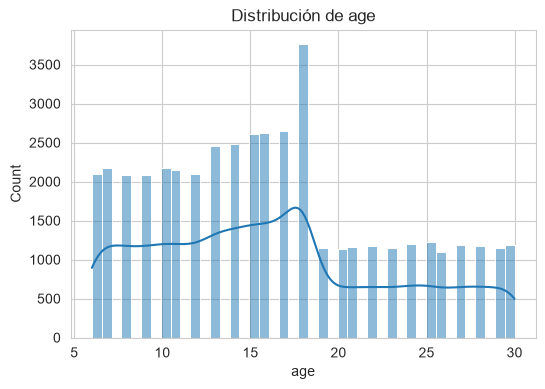

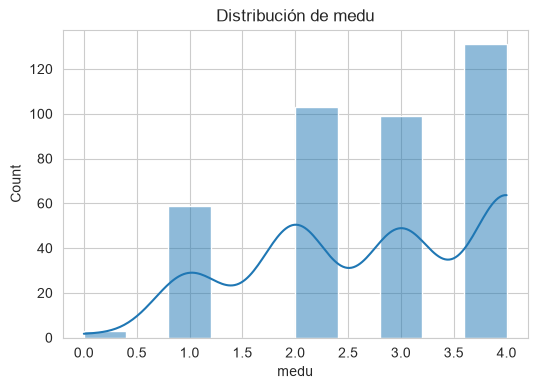

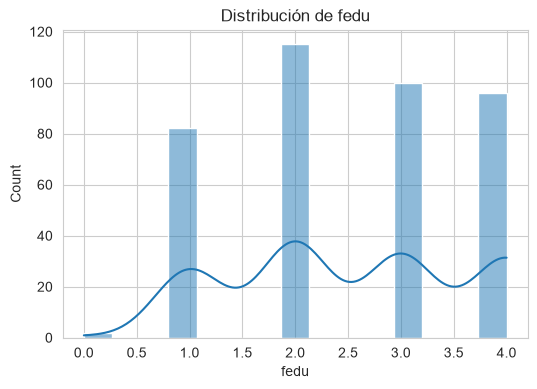

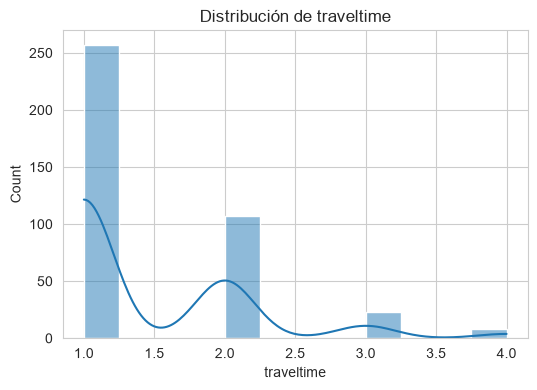

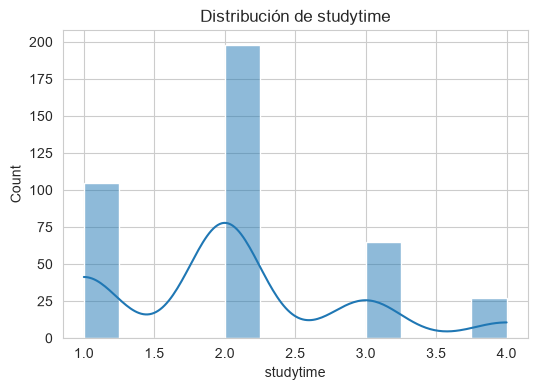

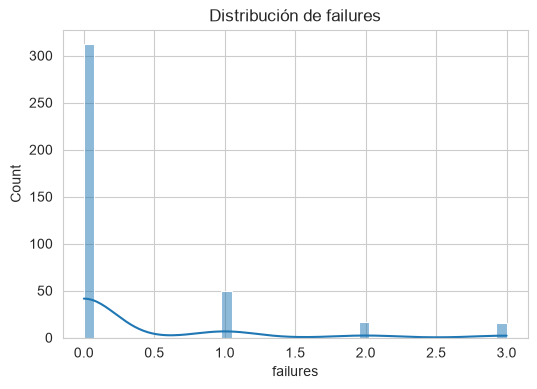

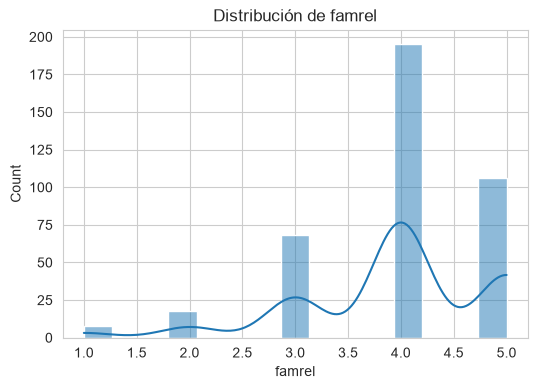

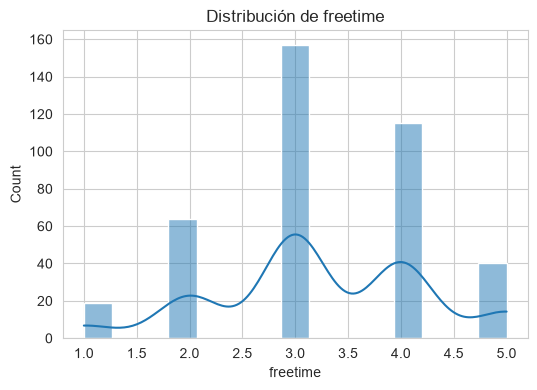

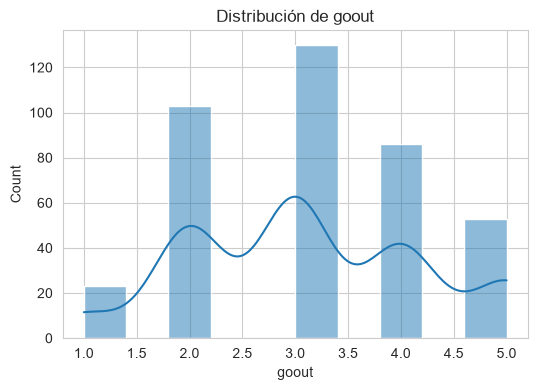

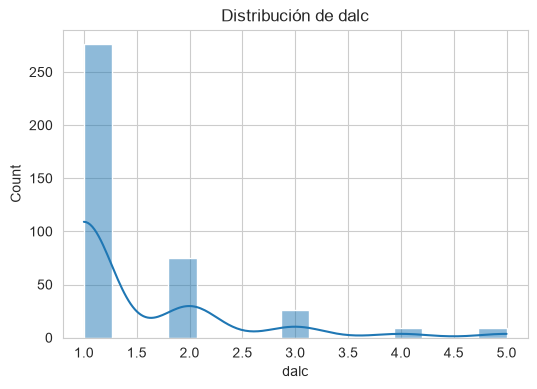

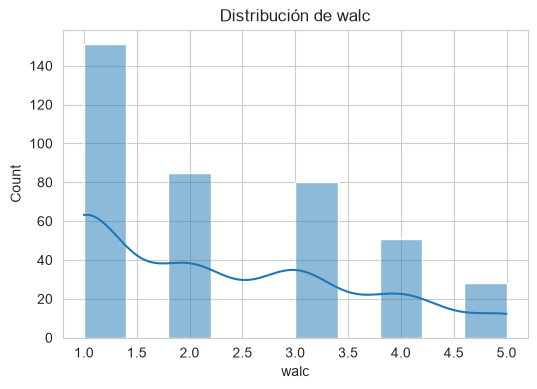

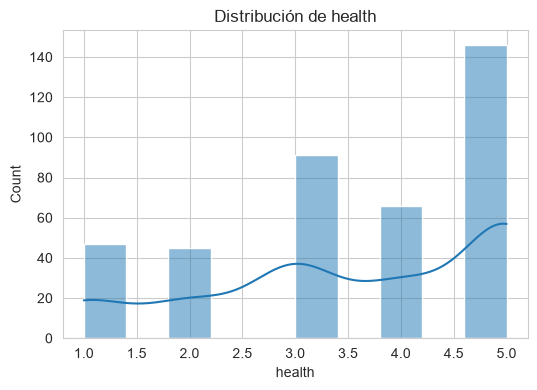

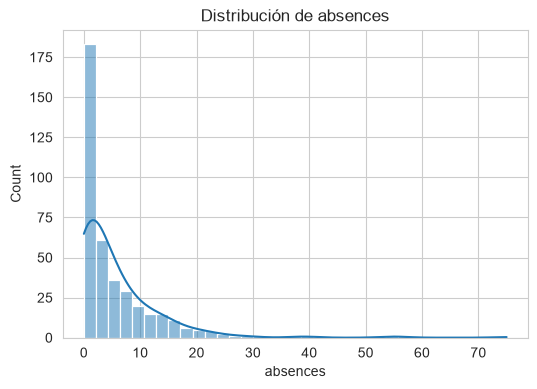

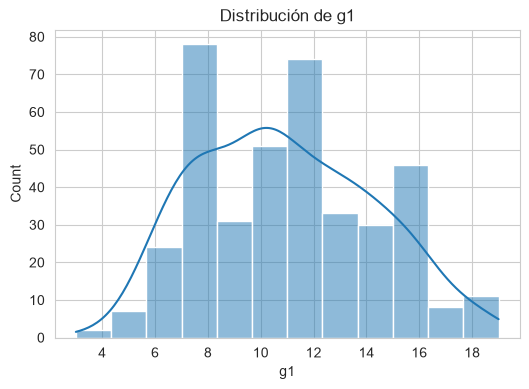

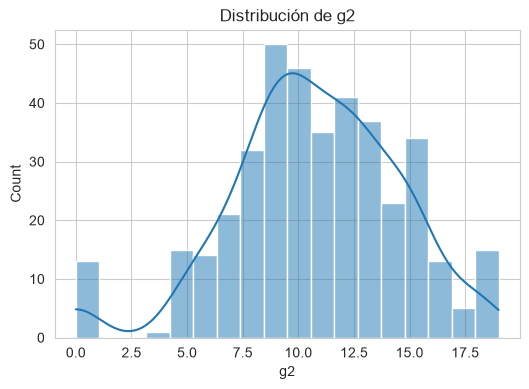

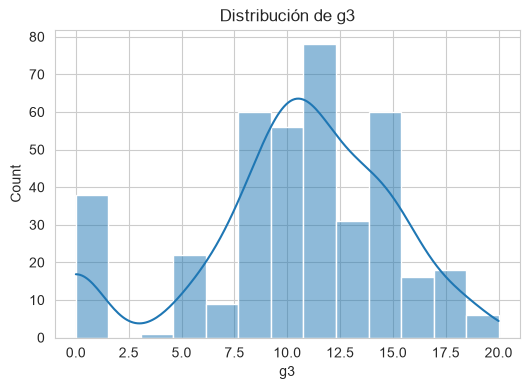

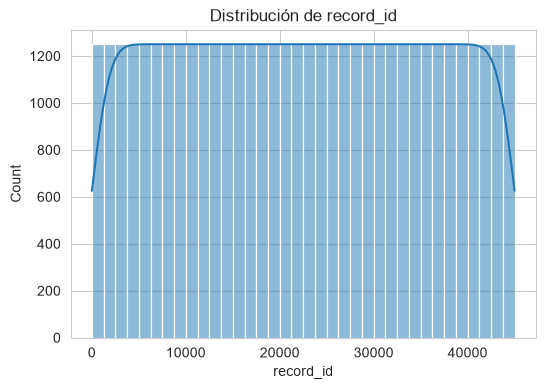

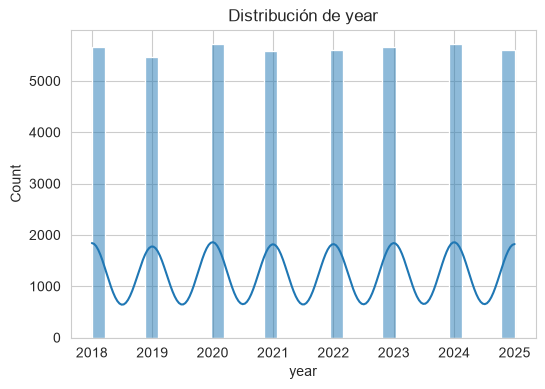

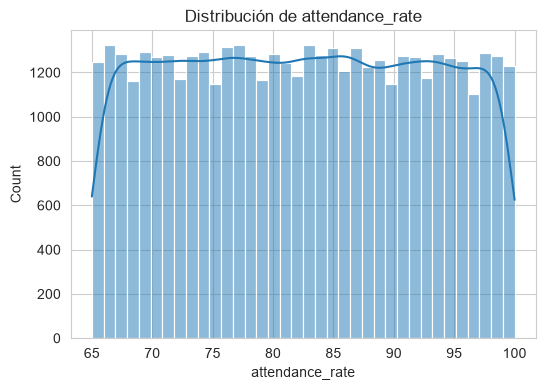

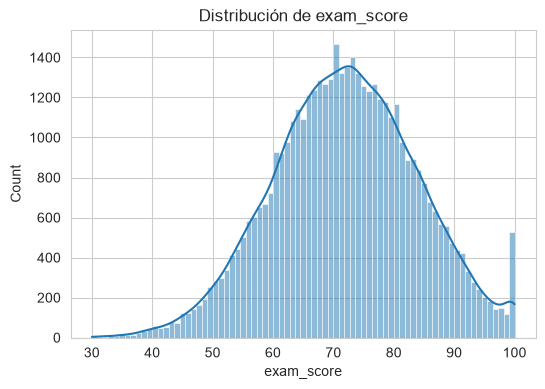

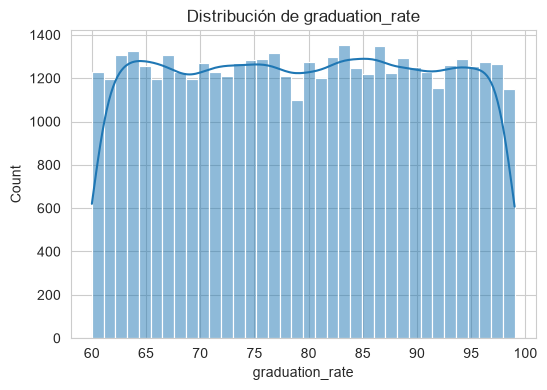

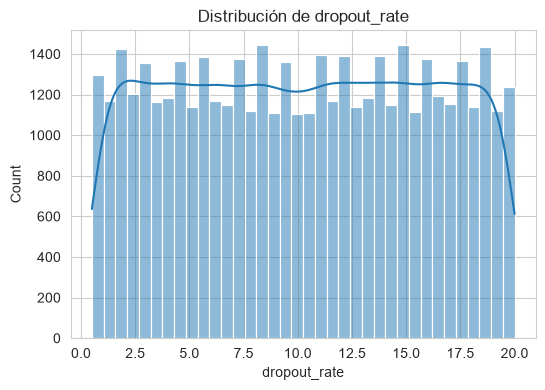

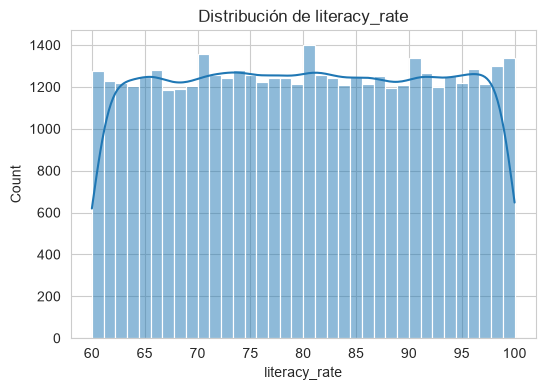

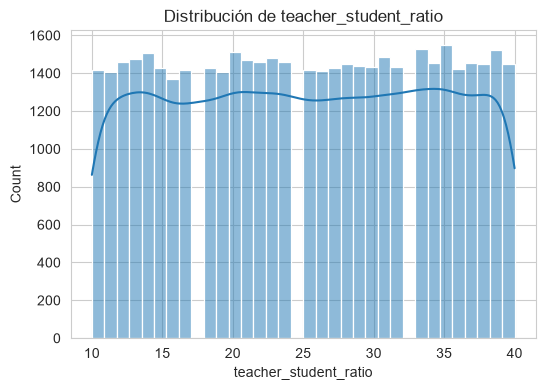

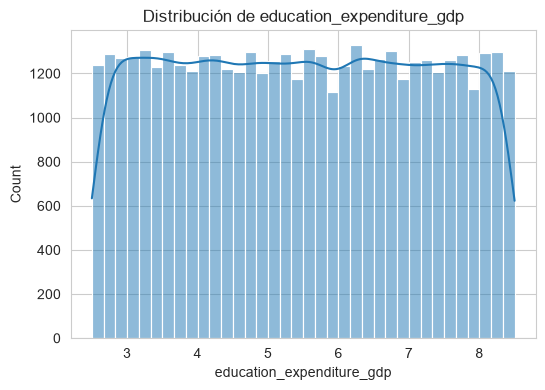

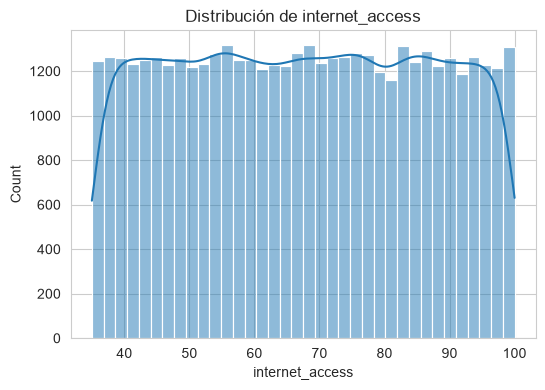

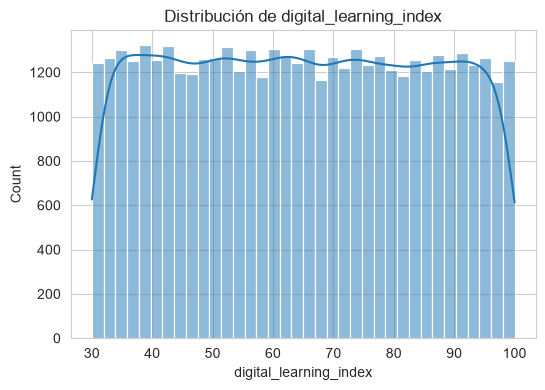

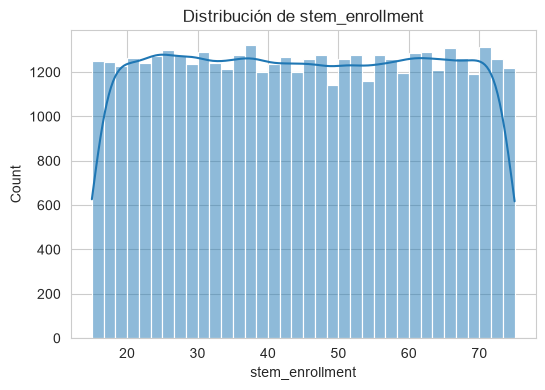

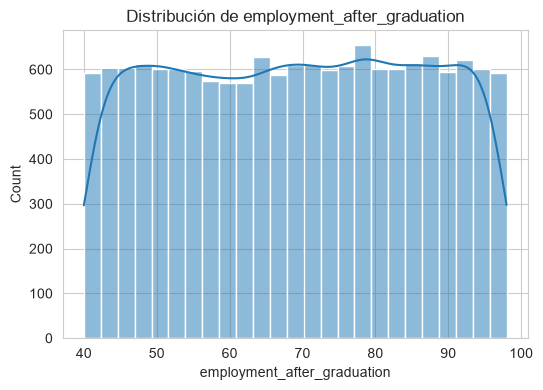

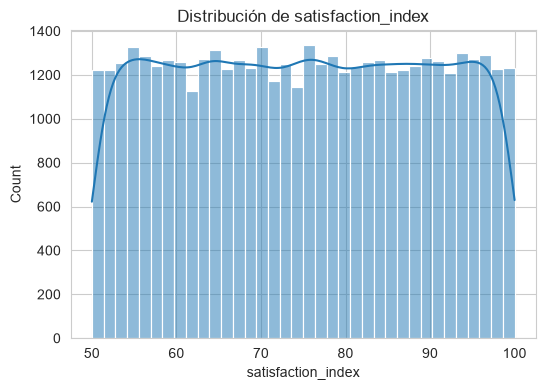

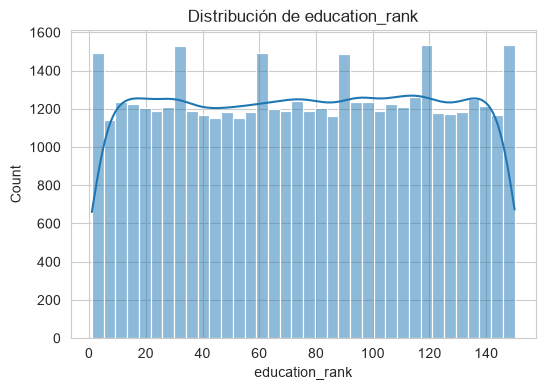

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df_final.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_final[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

# 13) Distribución de variables categóricas

C:\Users\alfon\AppData\Local\Temp\ipykernel_5304\2166047613.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_final.select_dtypes(include=['object']).columns


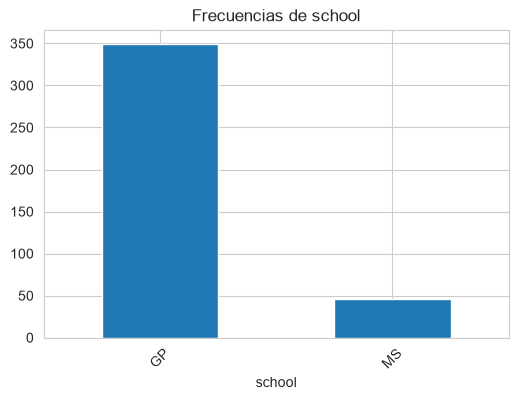

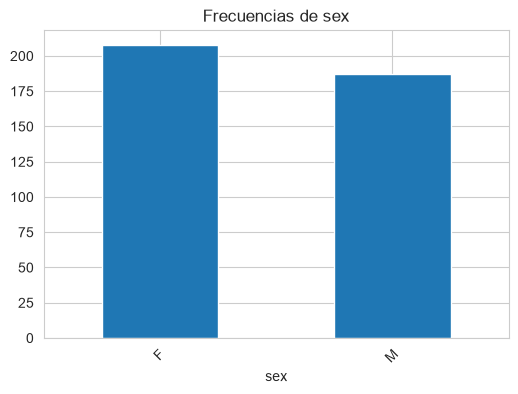

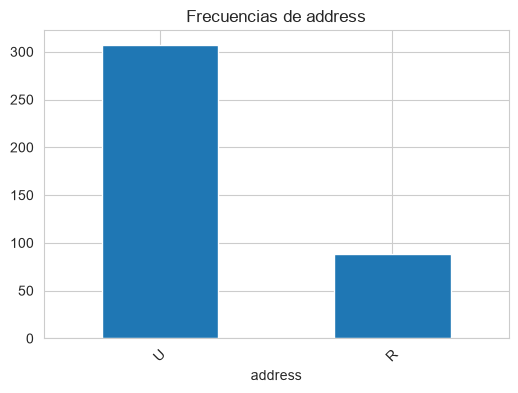

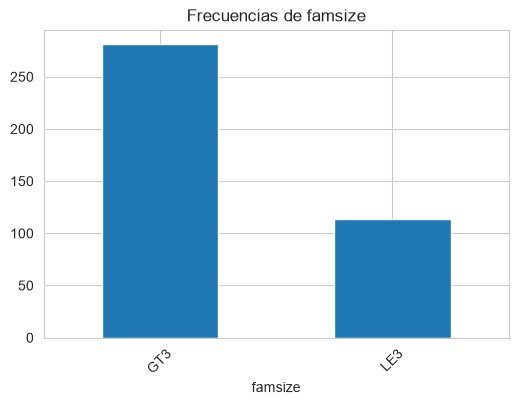

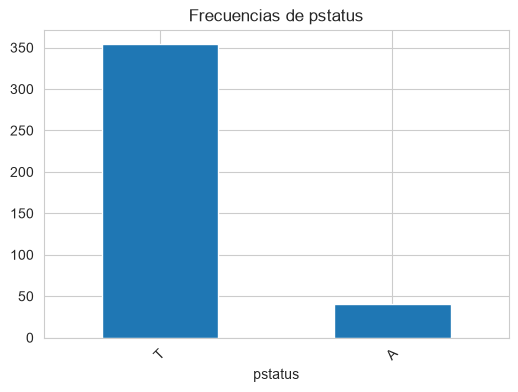

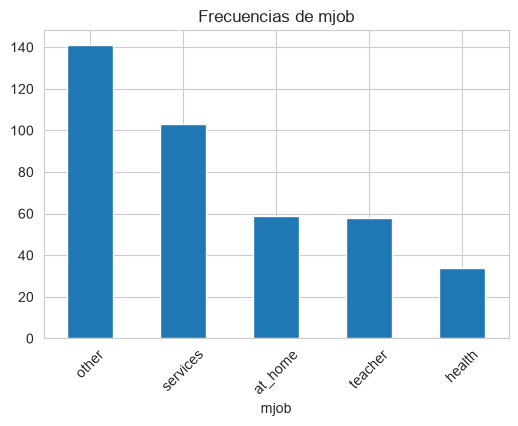

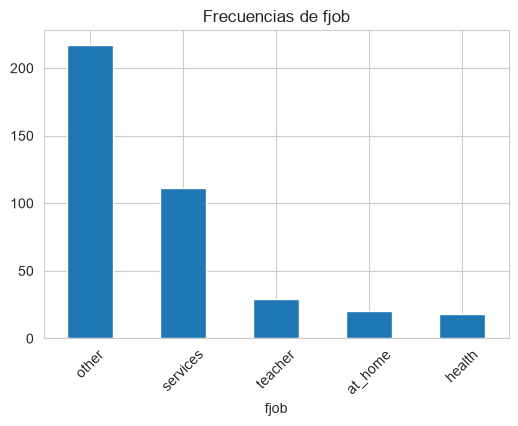

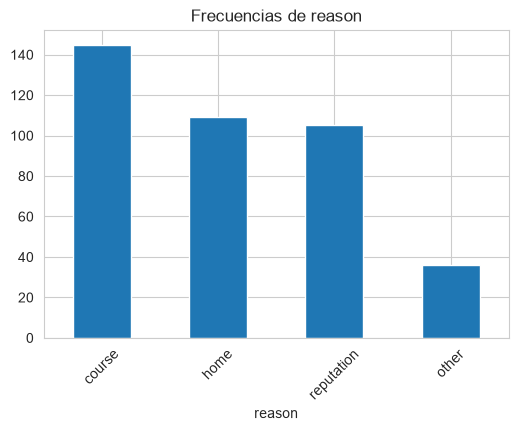

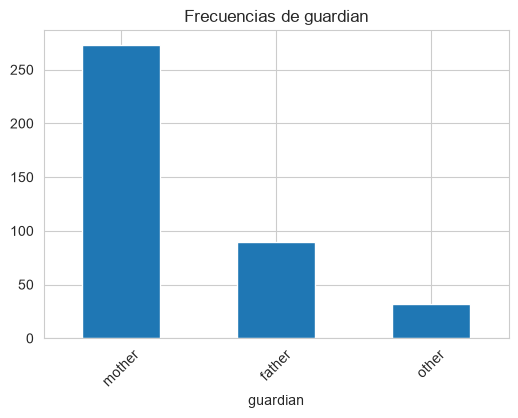

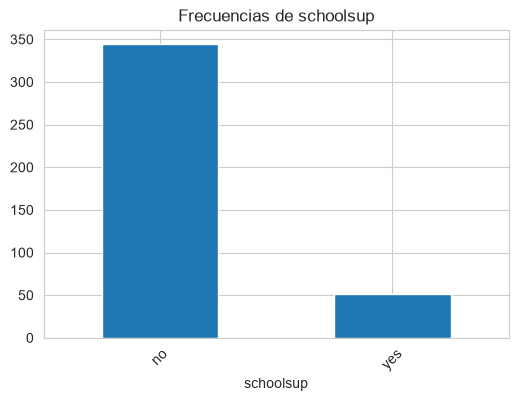

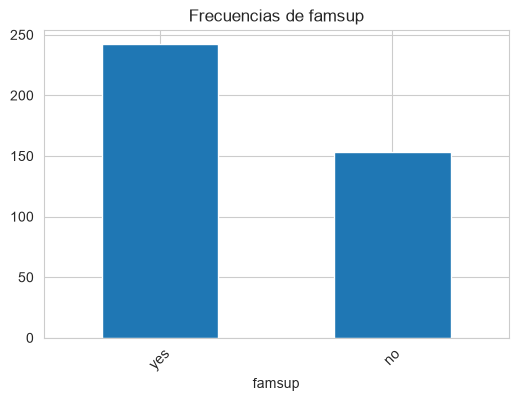

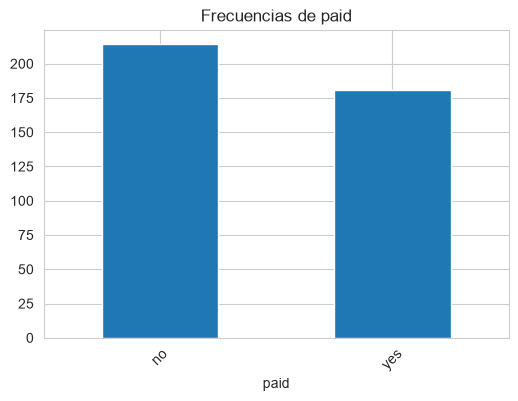

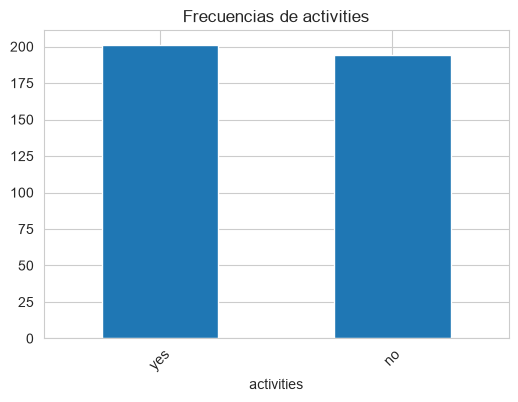

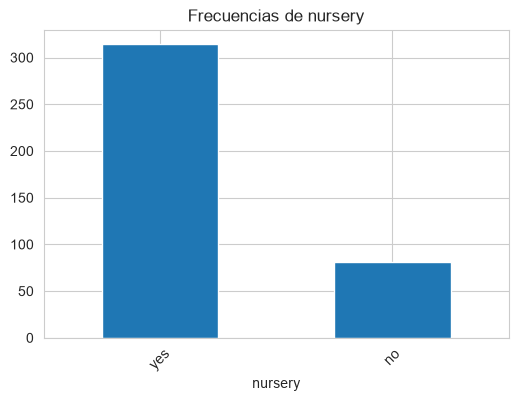

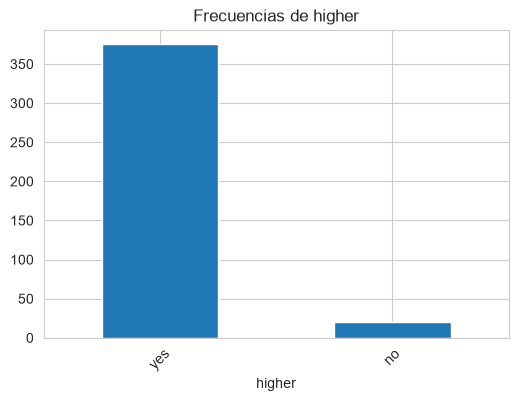

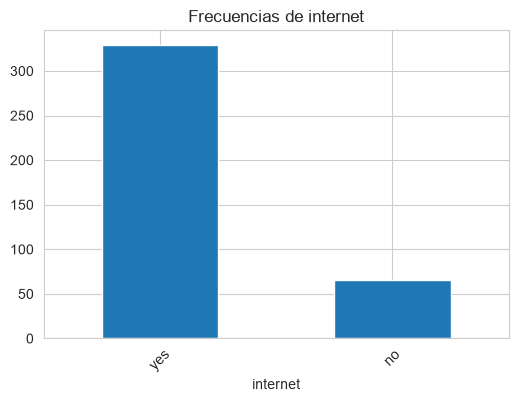

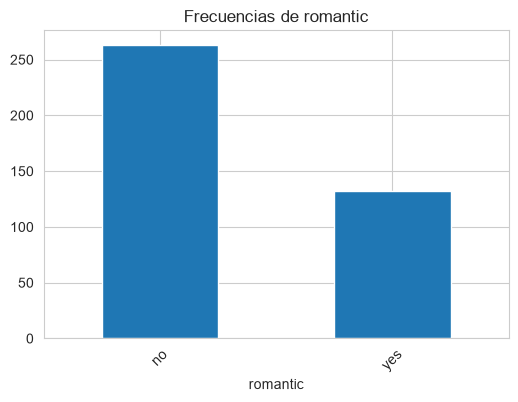

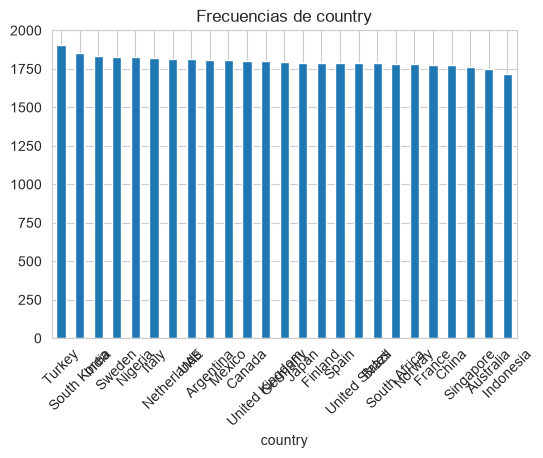

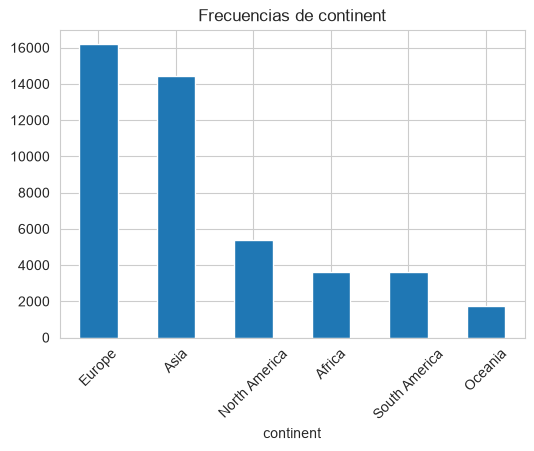

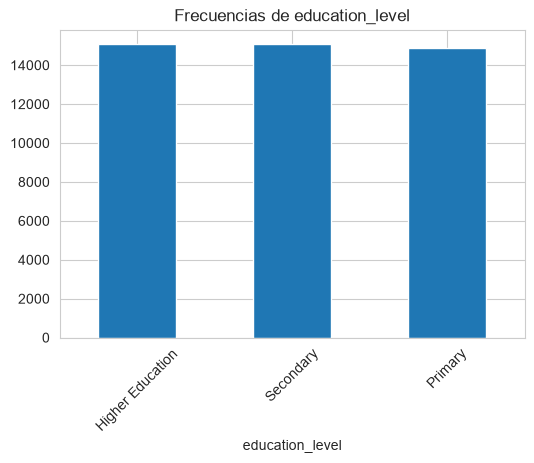

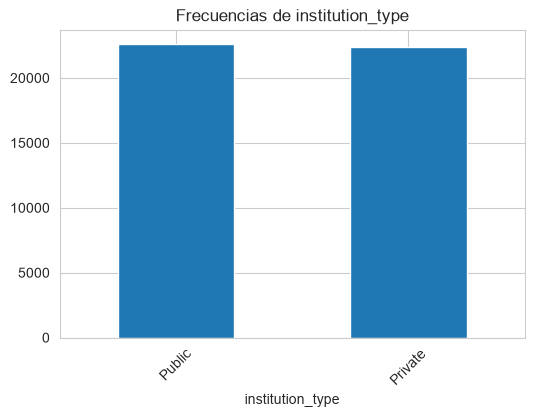

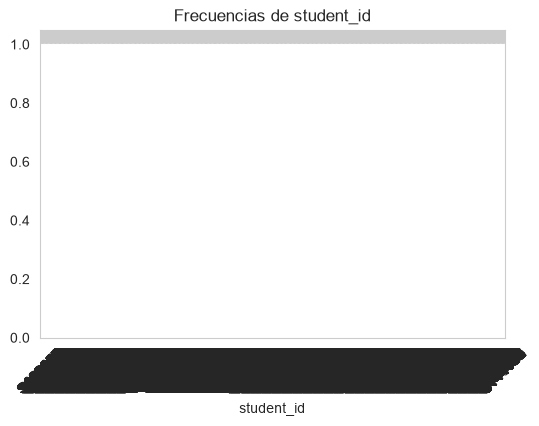

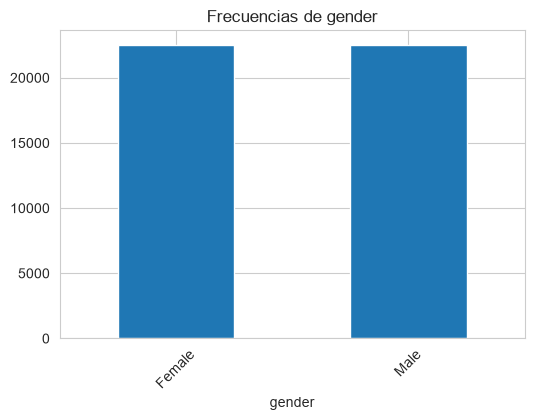

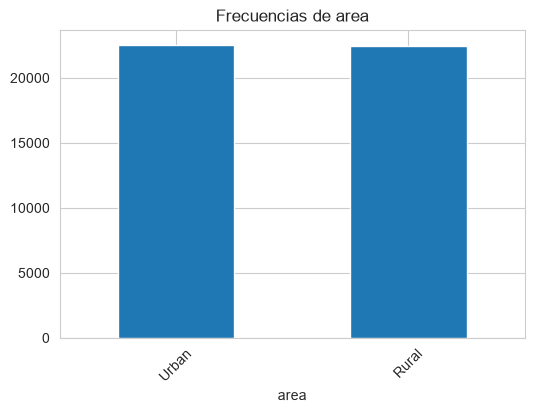

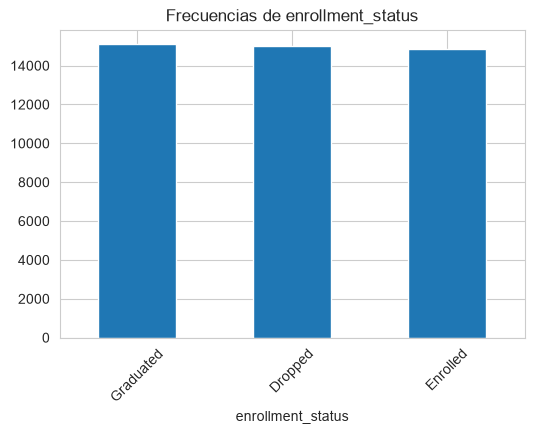

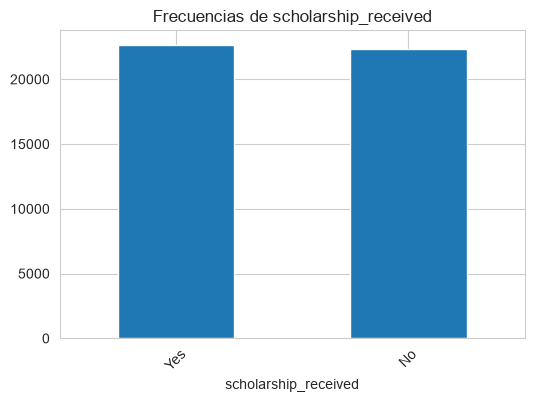

In [70]:
cat_cols = df_final.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    df_final[col].value_counts().plot(kind='bar')
    plt.title(f"Frecuencias de {col}")
    plt.xticks(rotation=45)
    plt.show()

# 14) Boxplots para todas las variables numéricas

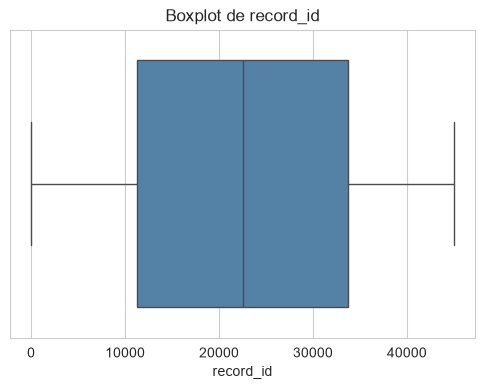

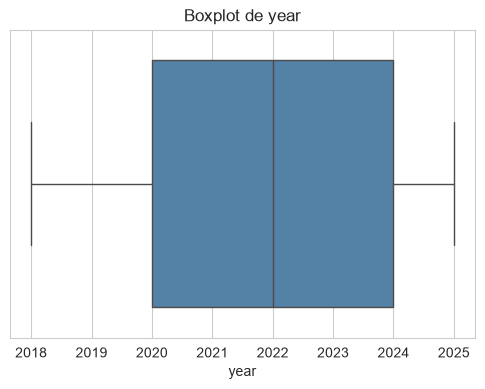

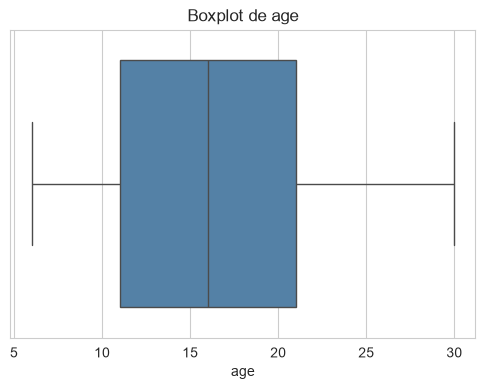

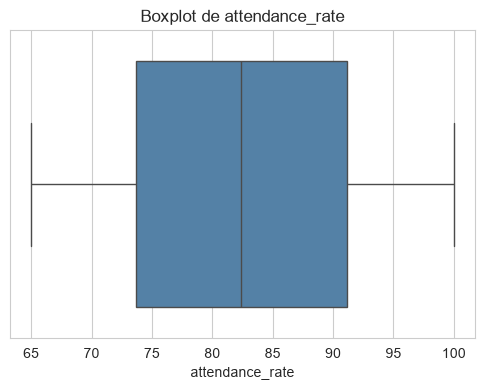

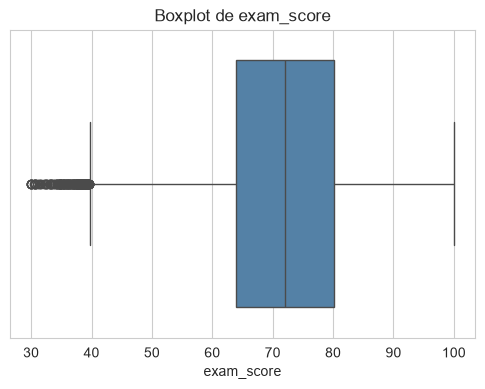

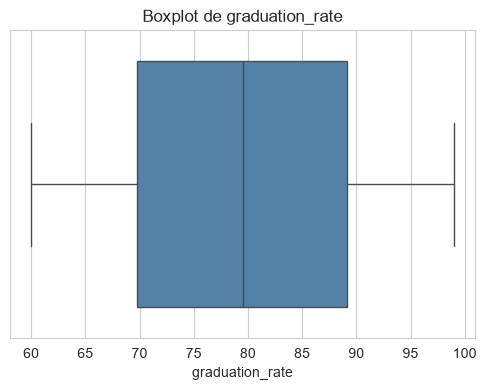

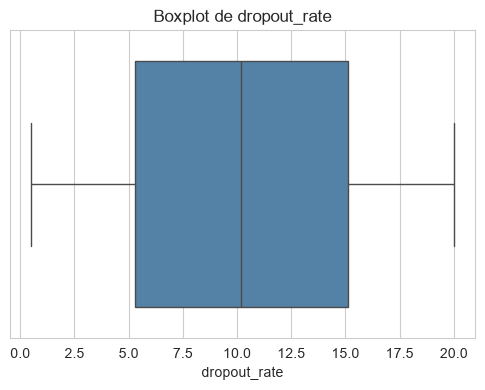

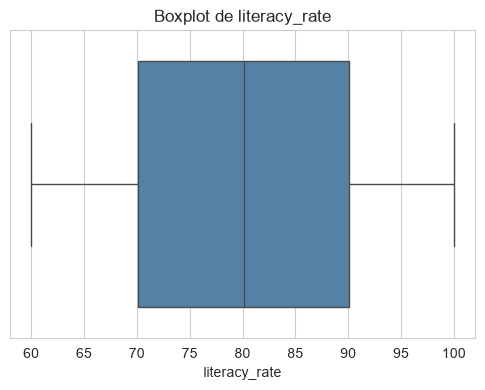

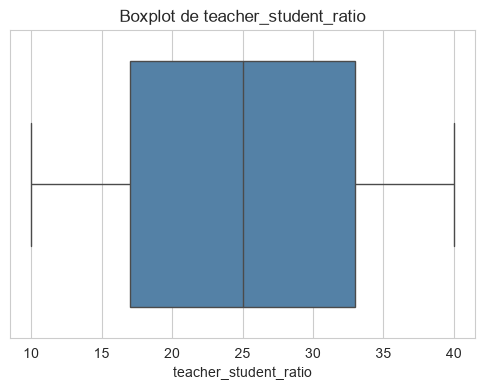

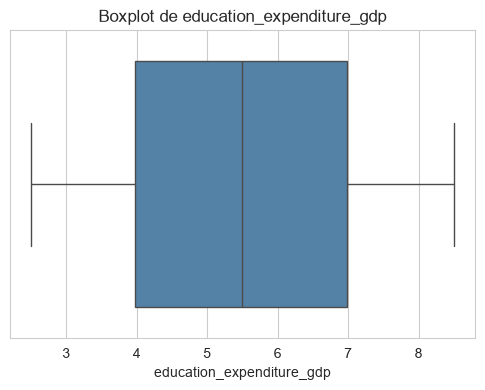

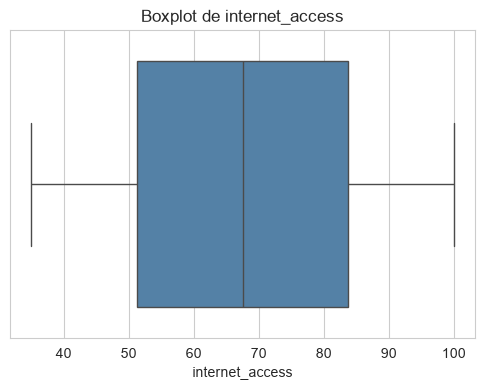

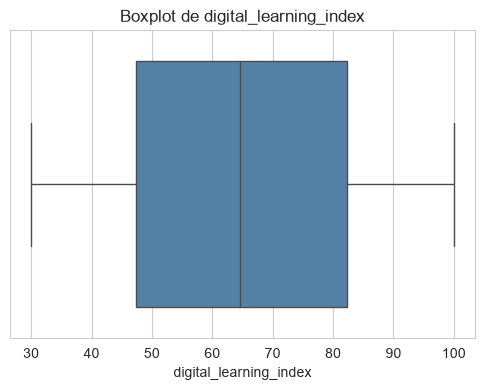

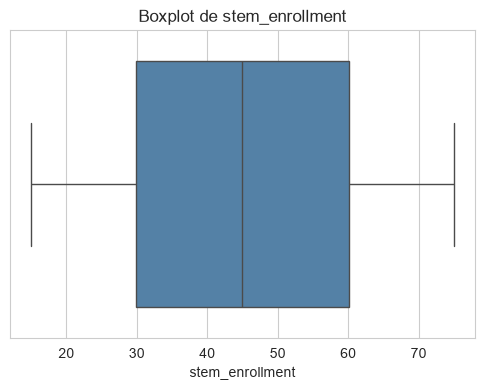

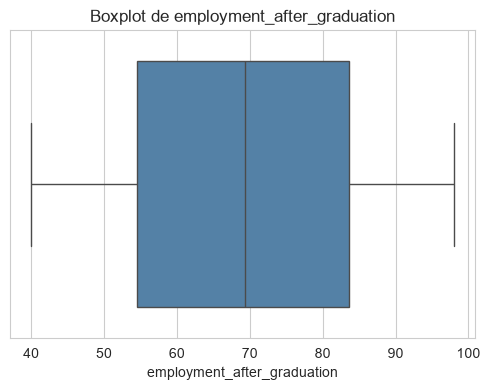

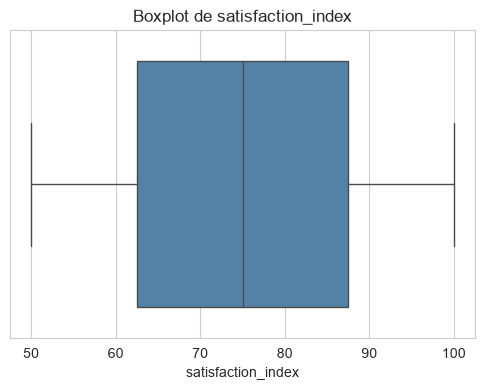

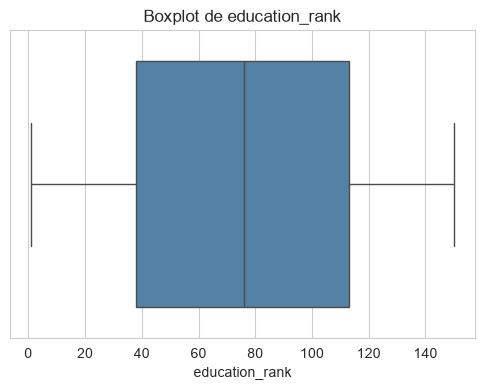

In [72]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_world_clean[col], color="steelblue")
    plt.title(f"Boxplot de {col}")
    plt.show()

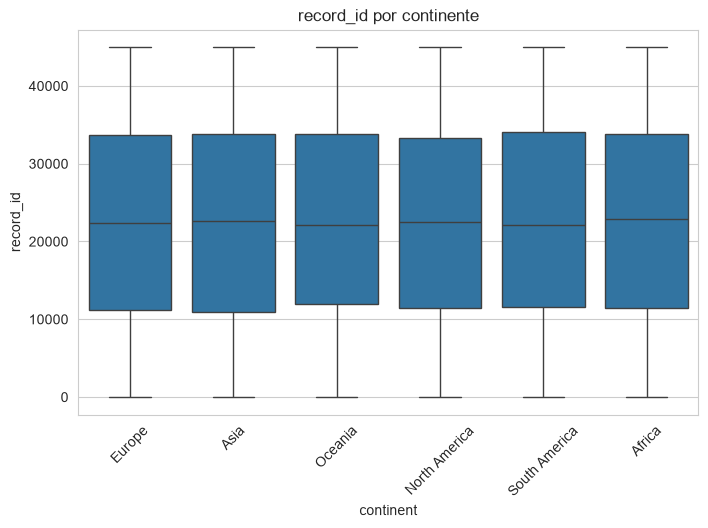

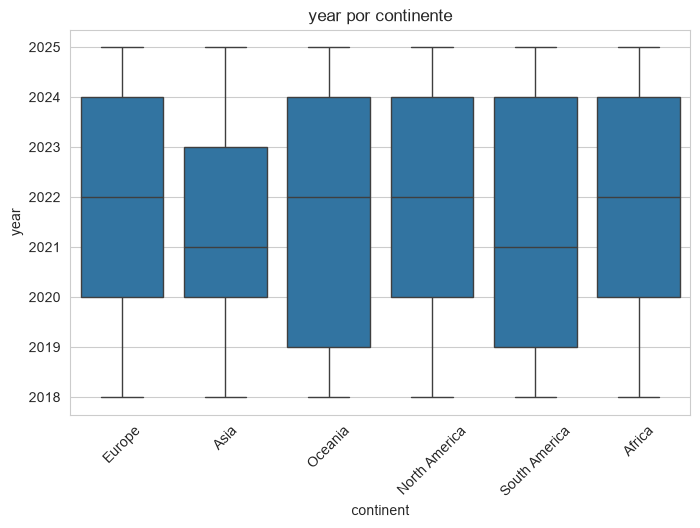

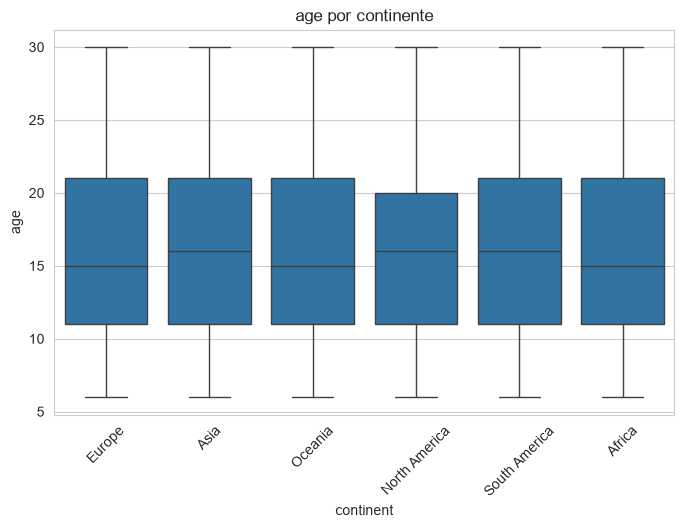

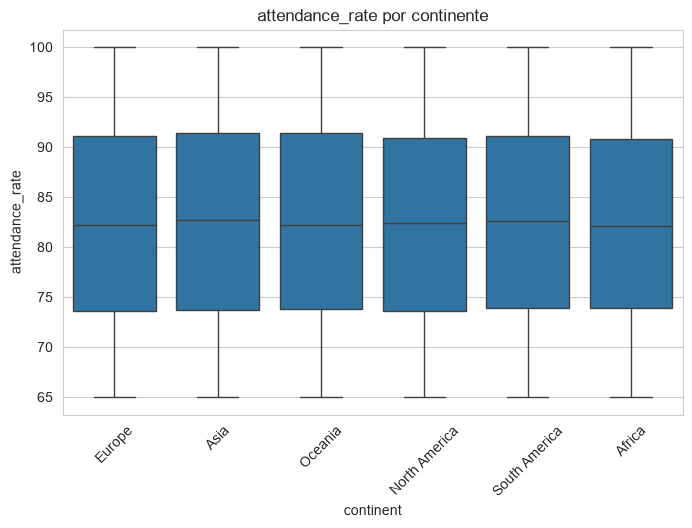

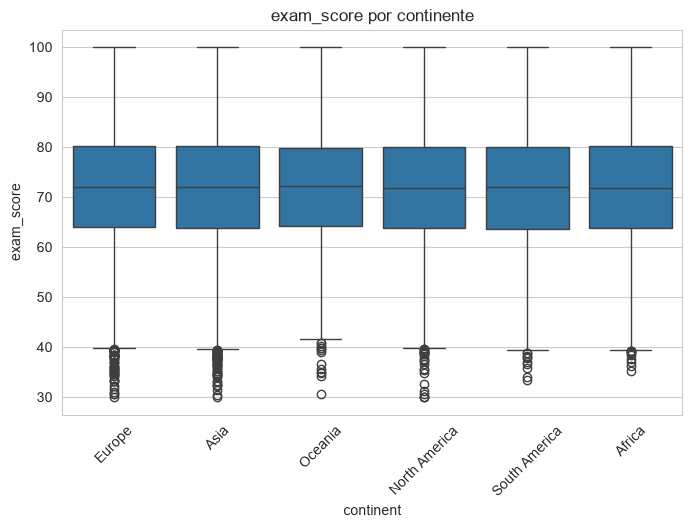

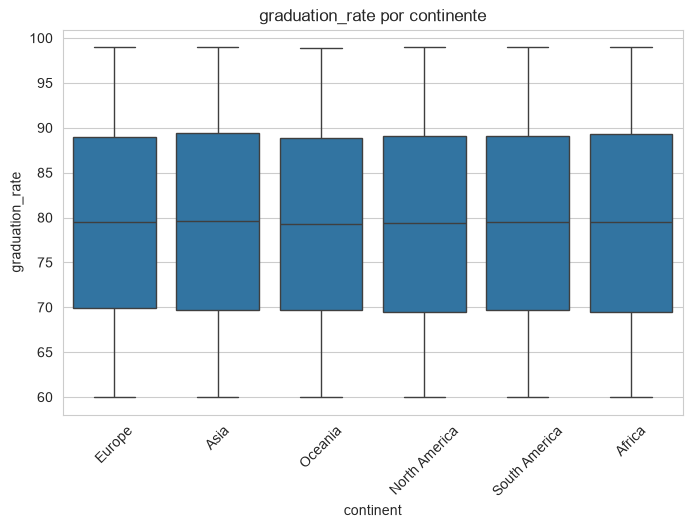

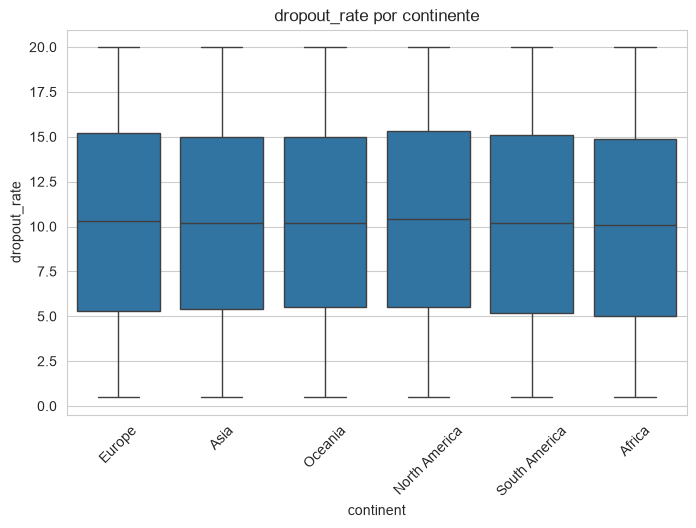

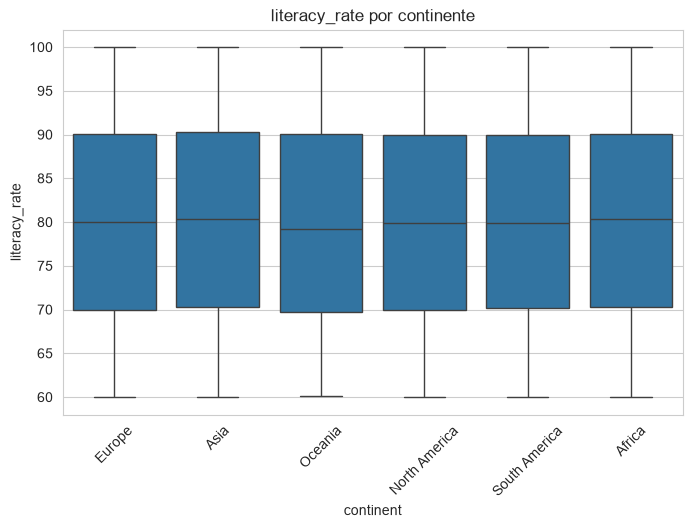

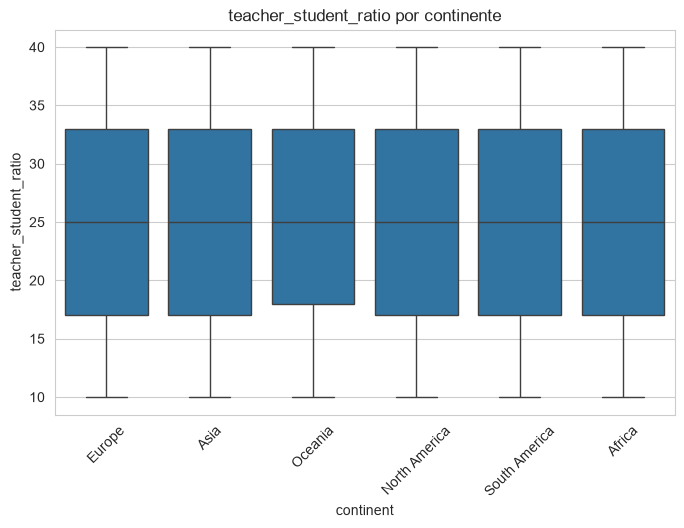

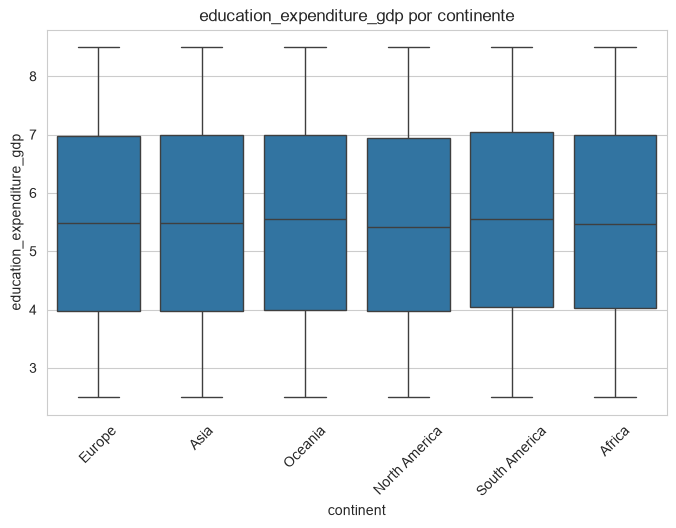

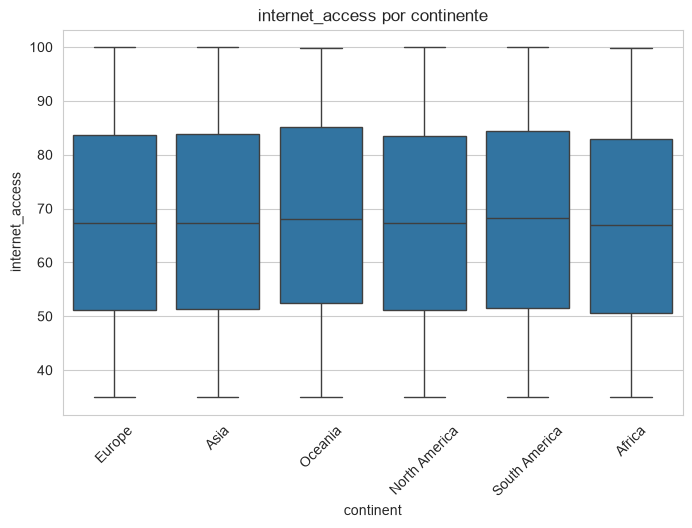

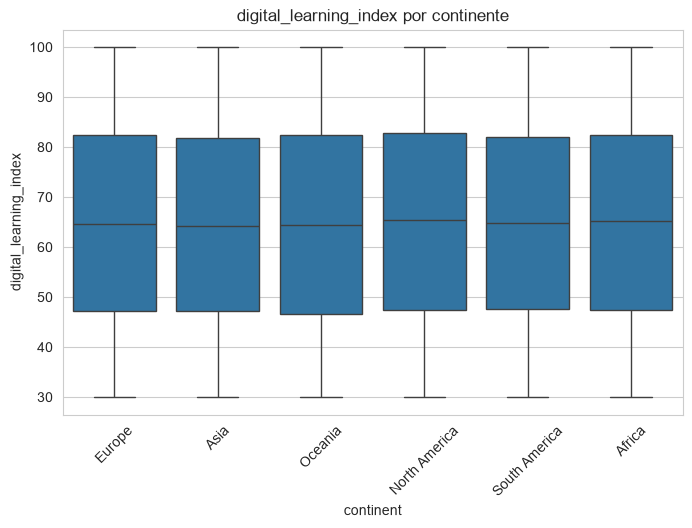

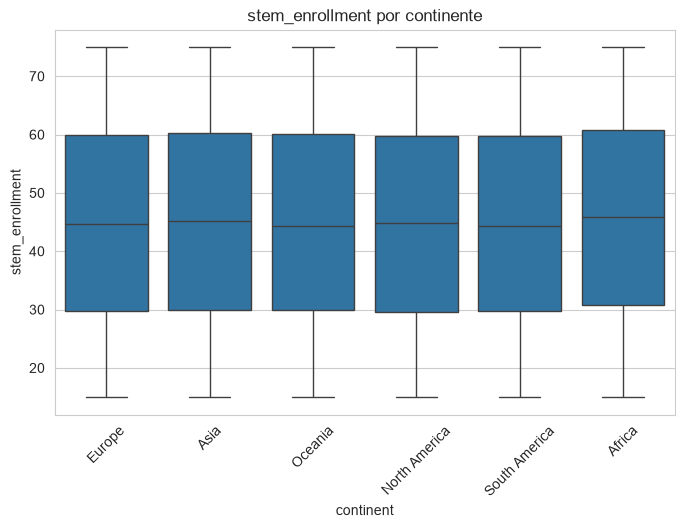

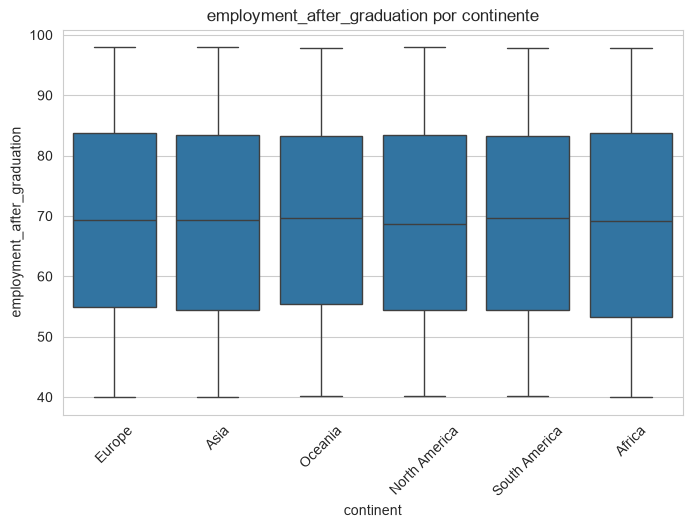

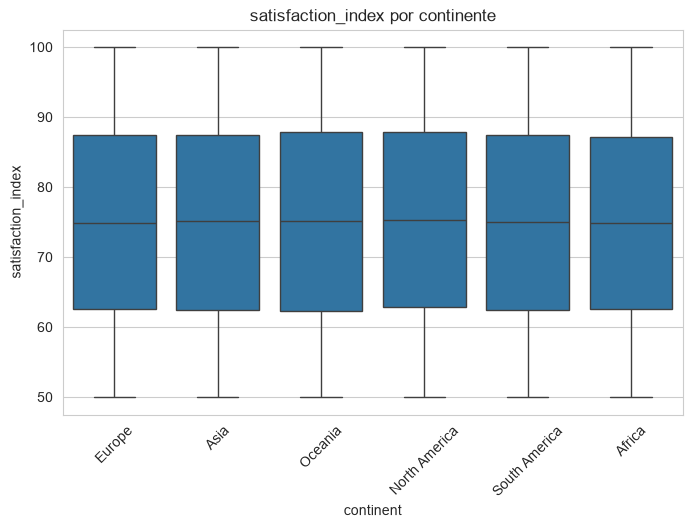

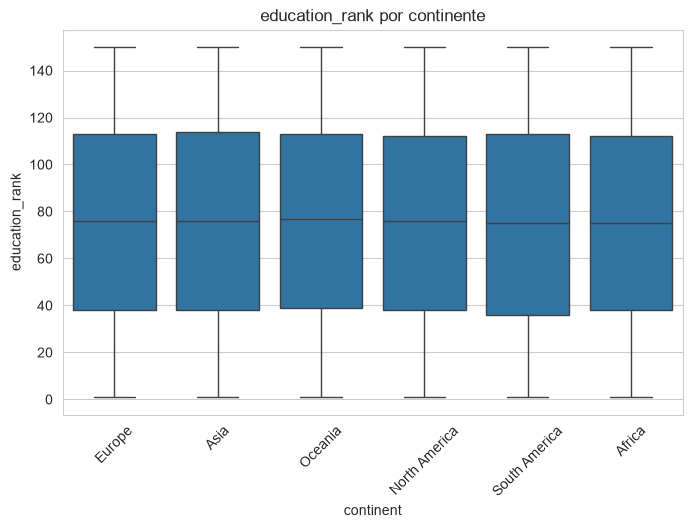

In [74]:
##comparar por continente:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_world_clean, x="continent", y=col)
    plt.title(f"{col} por continente")
    plt.xticks(rotation=45)
    plt.show()

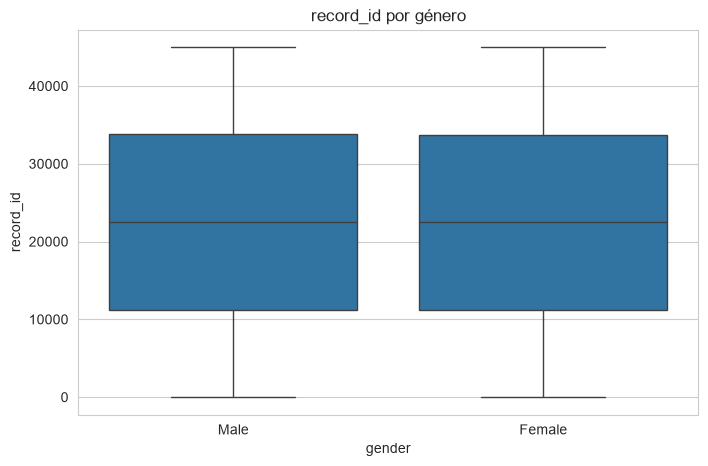

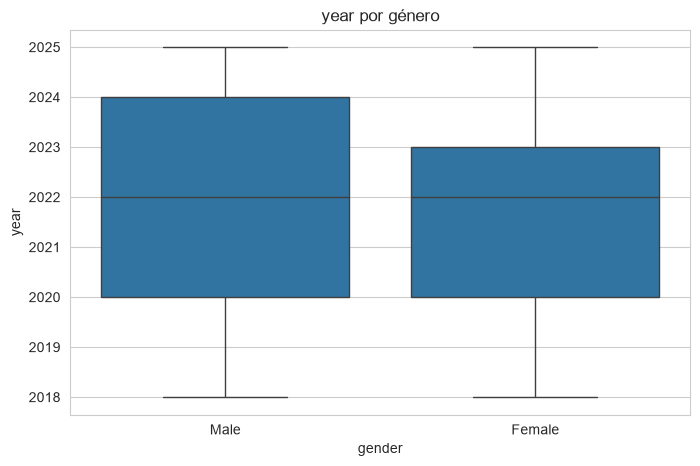

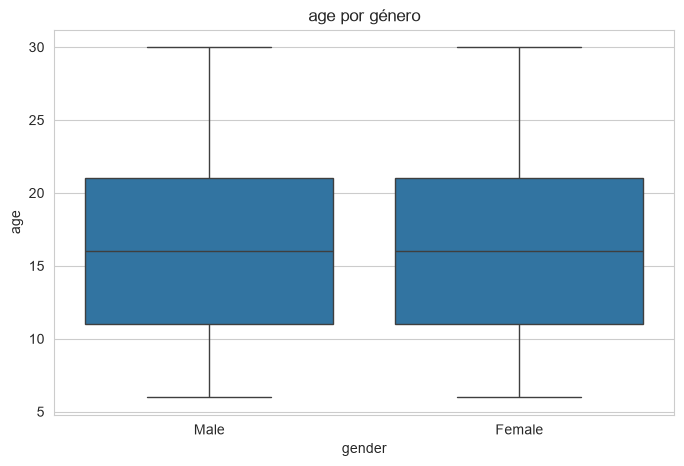

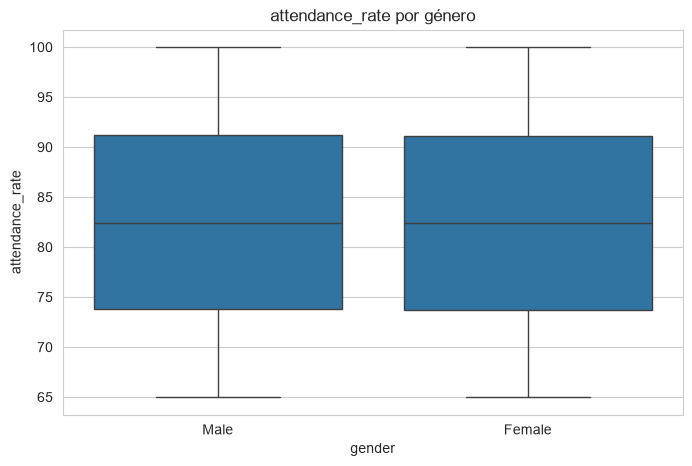

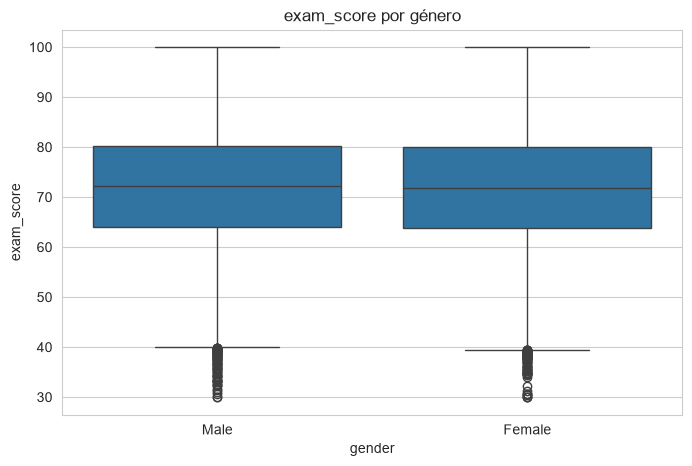

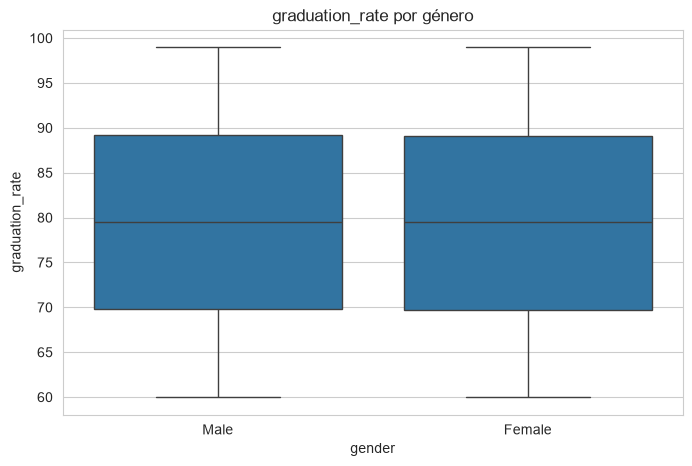

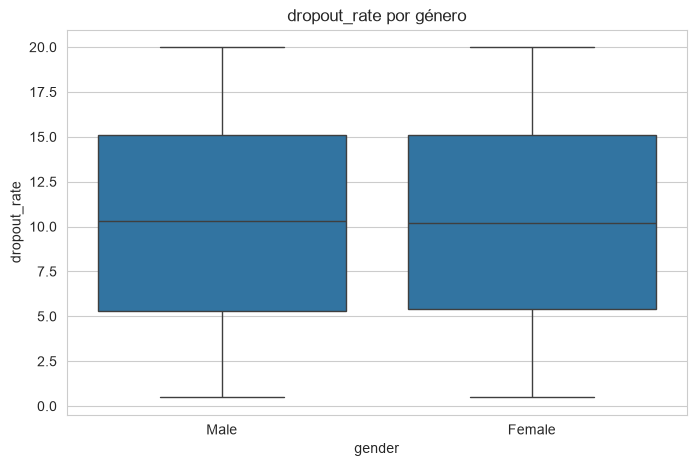

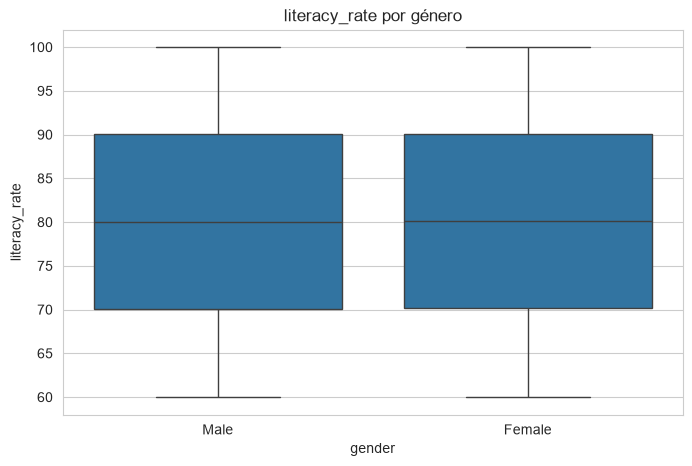

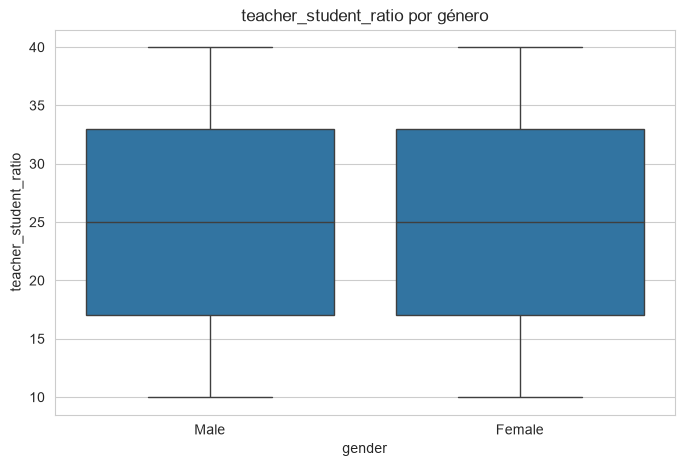

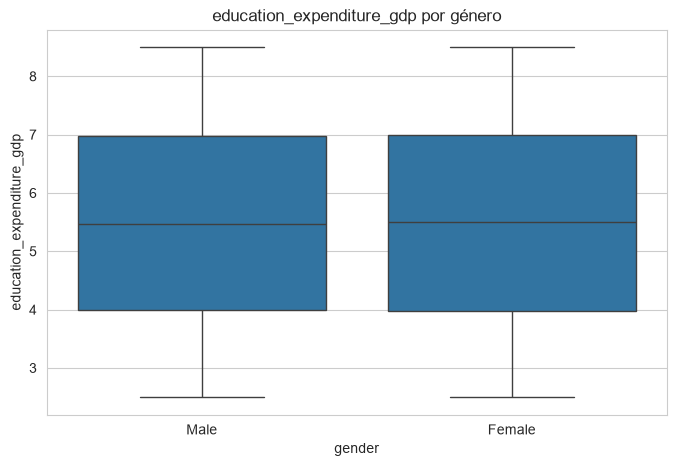

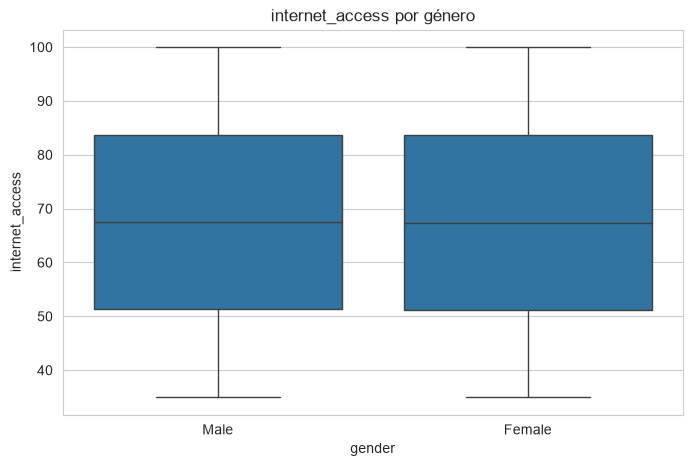

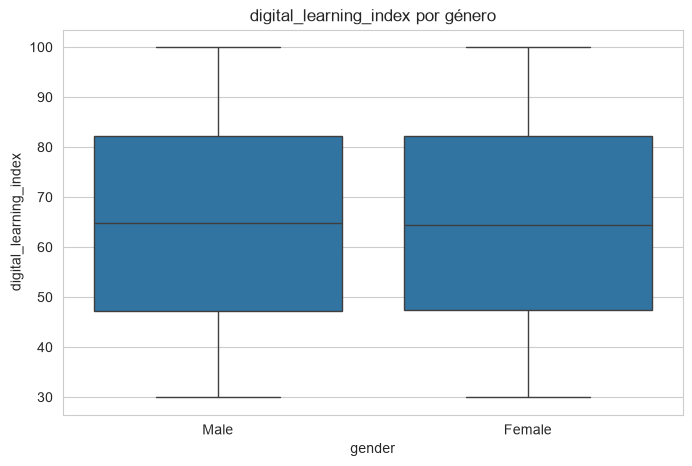

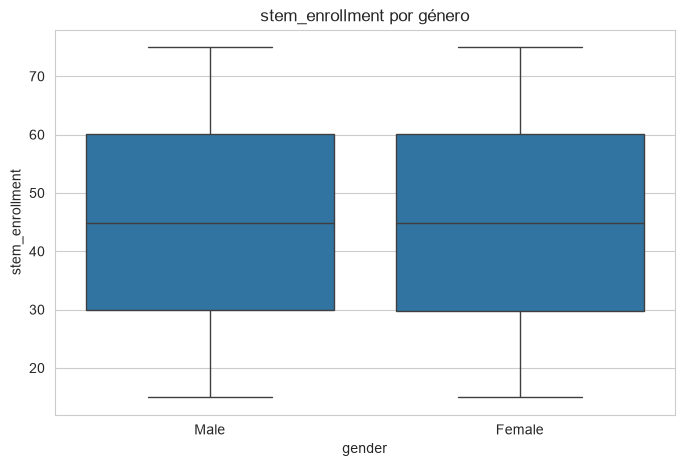

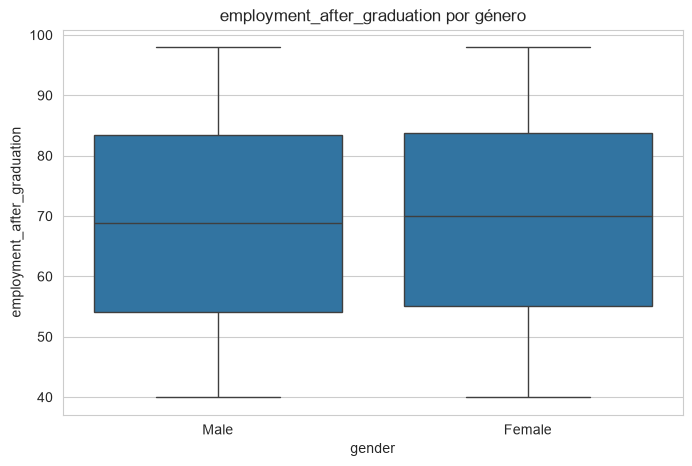

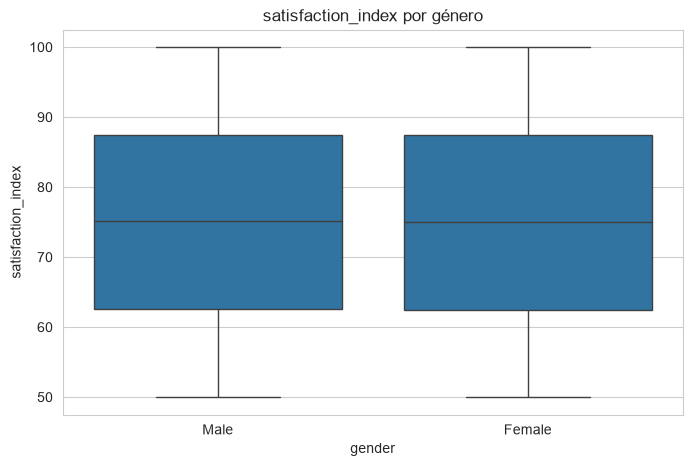

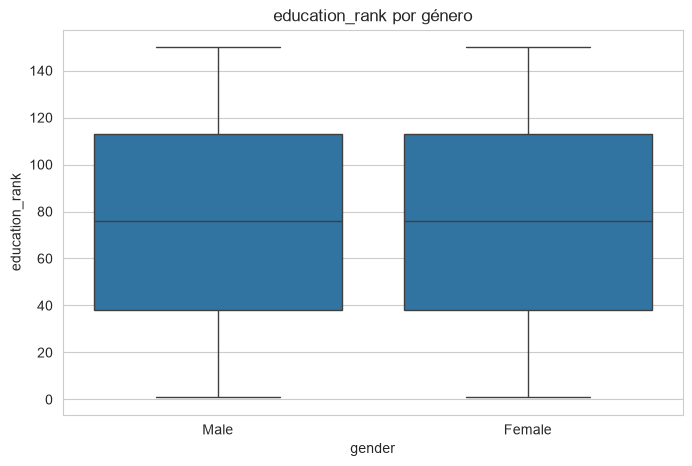

In [75]:
## Por genero
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_world_clean, x="gender", y=col)
    plt.title(f"{col} por género")
    plt.show()

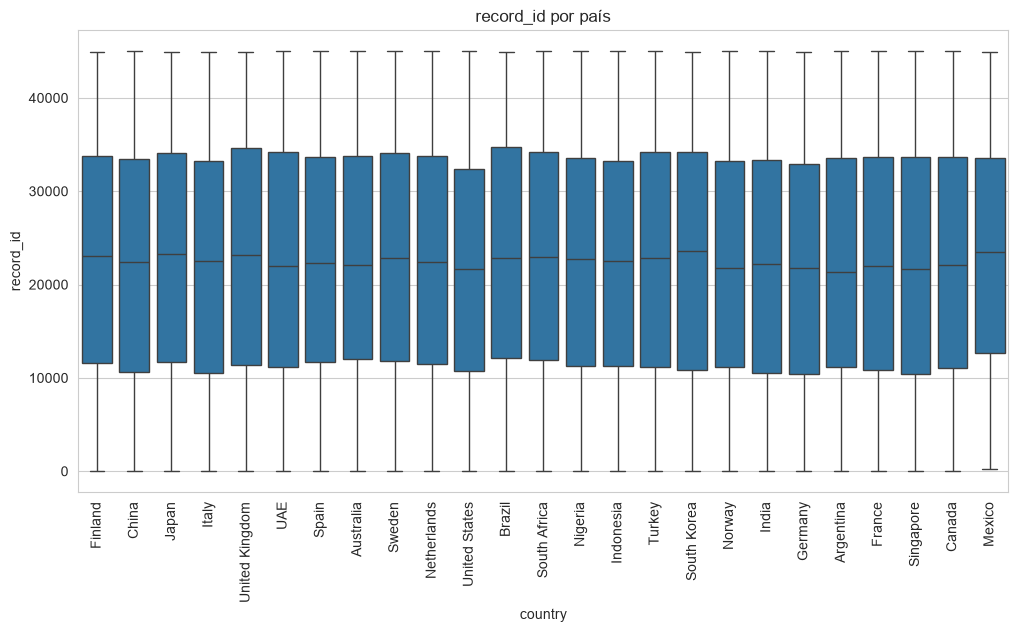

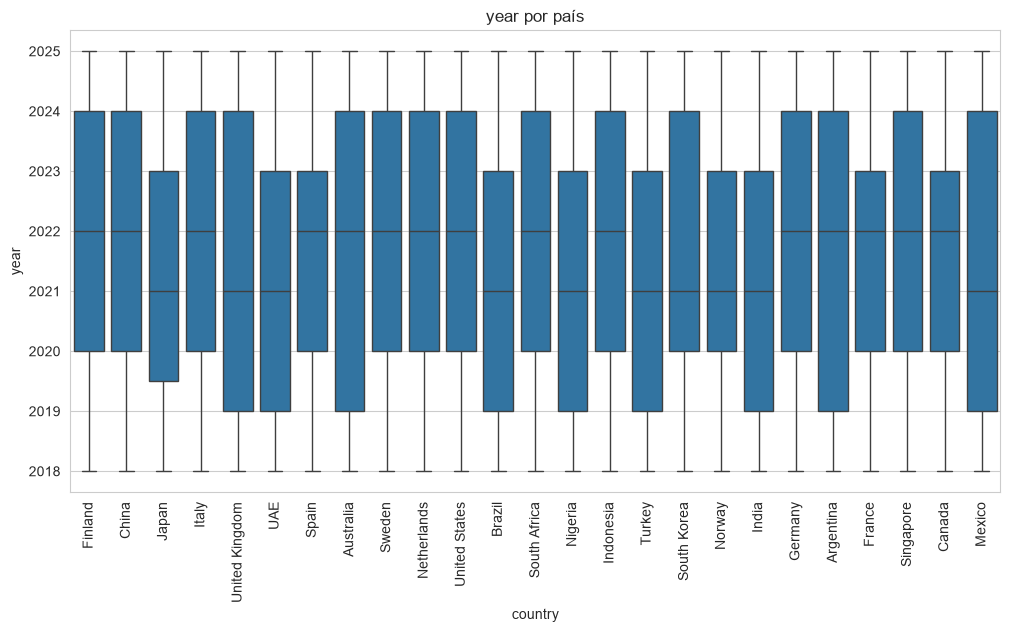

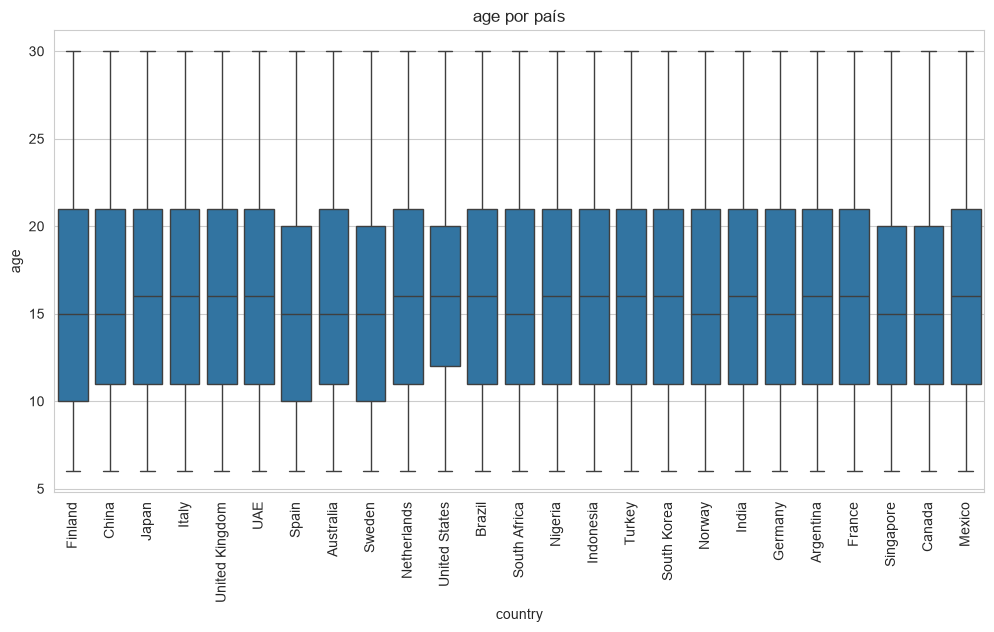

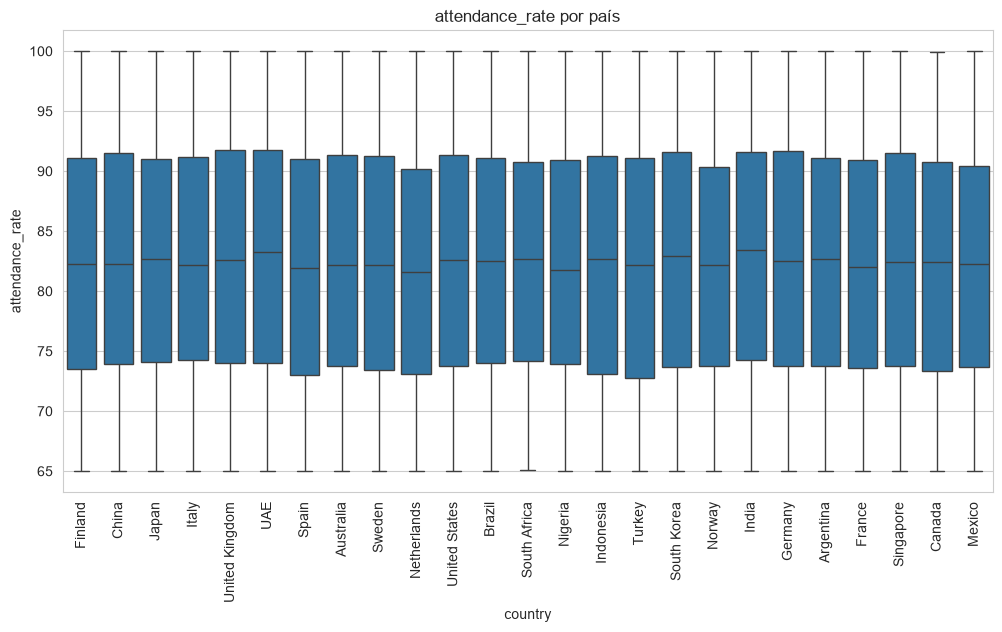

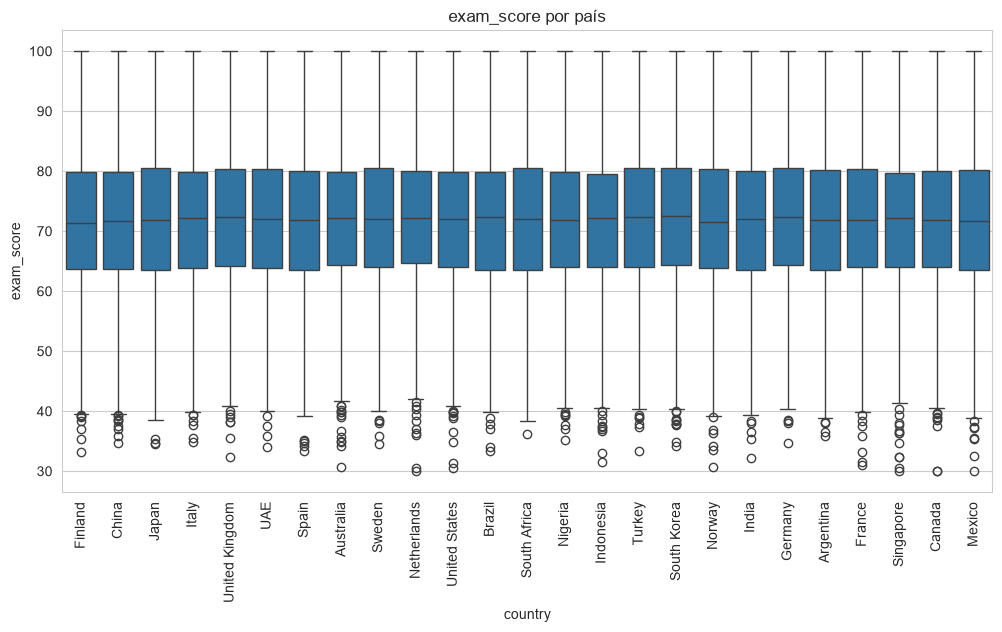

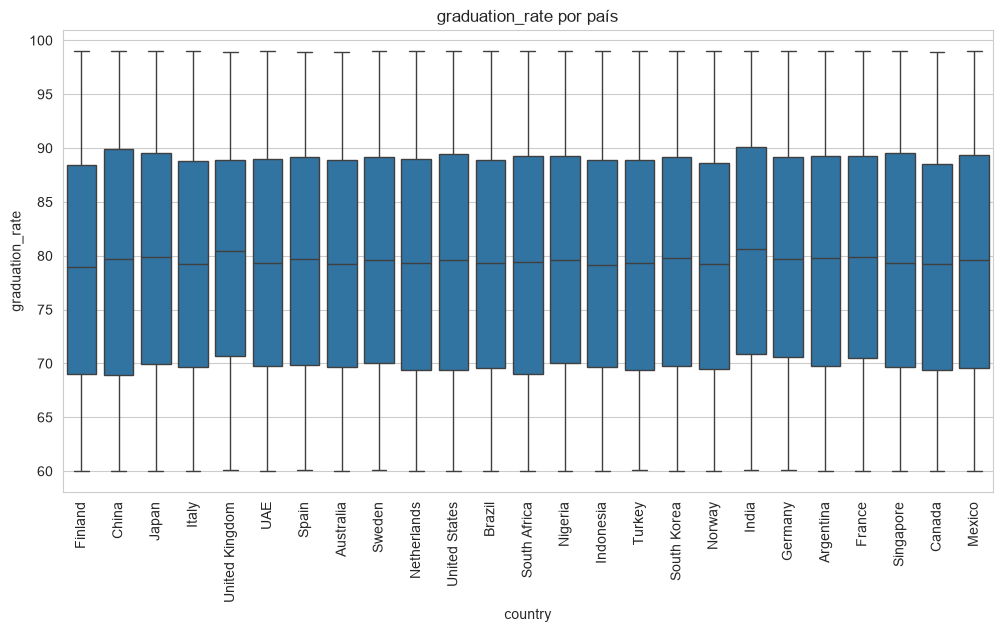

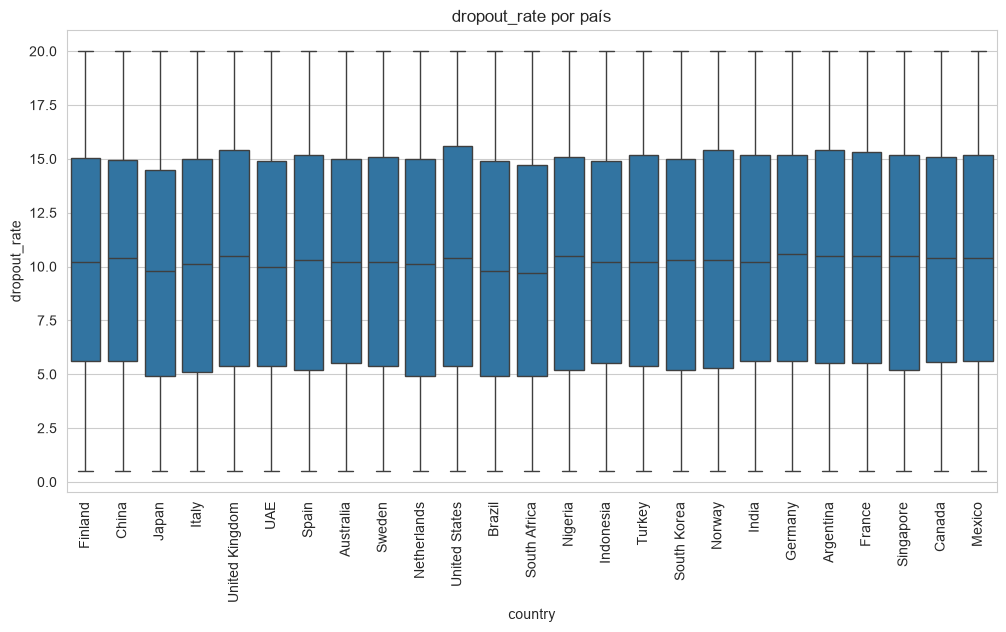

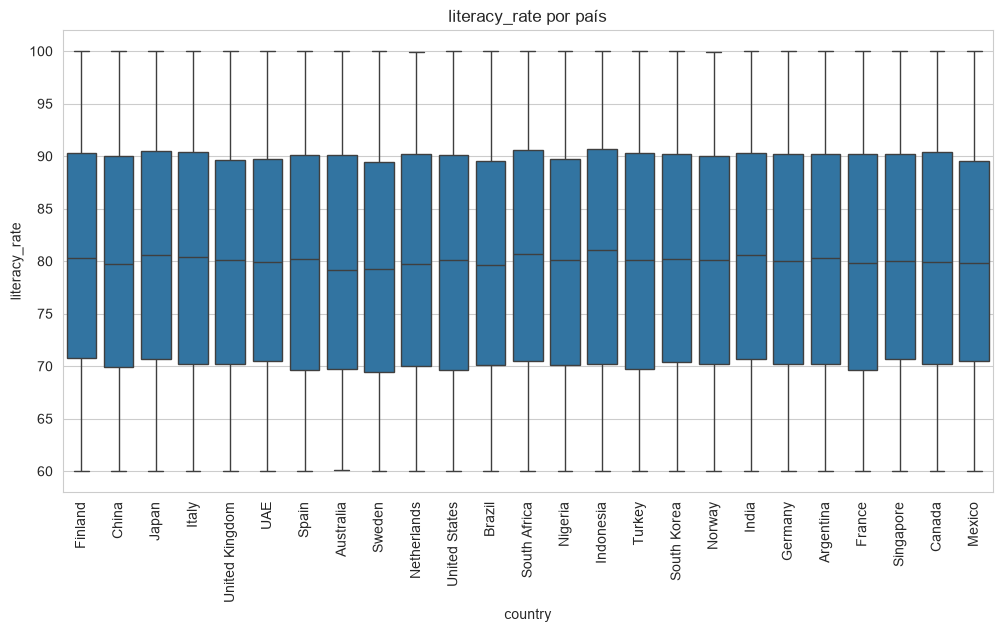

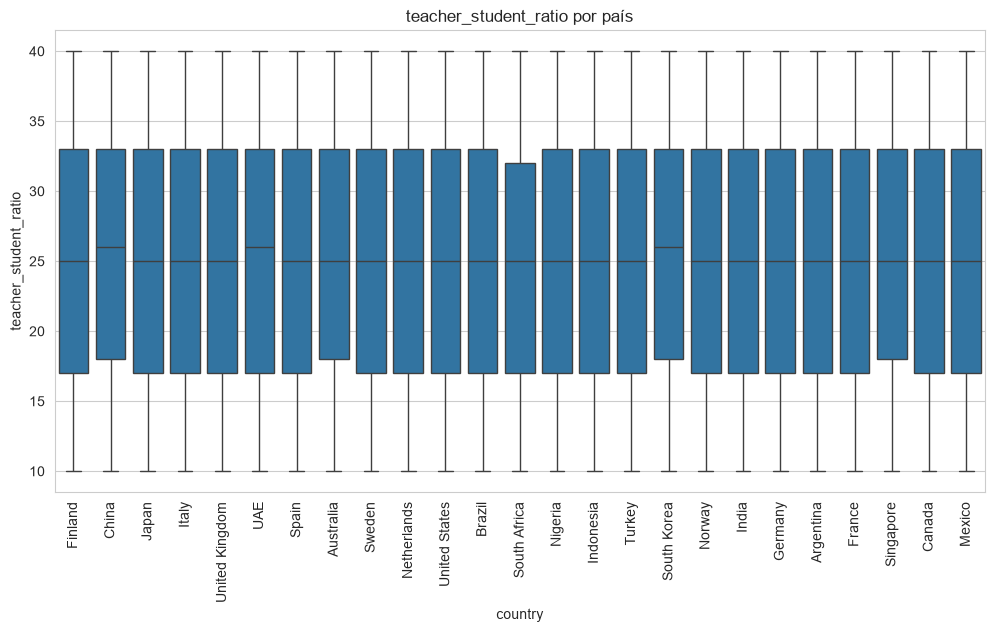

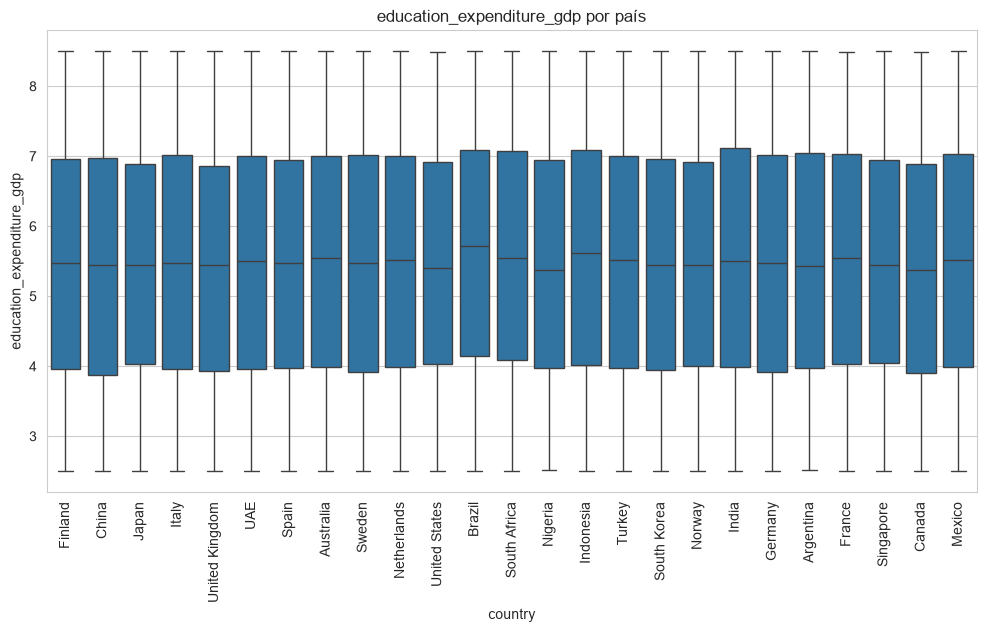

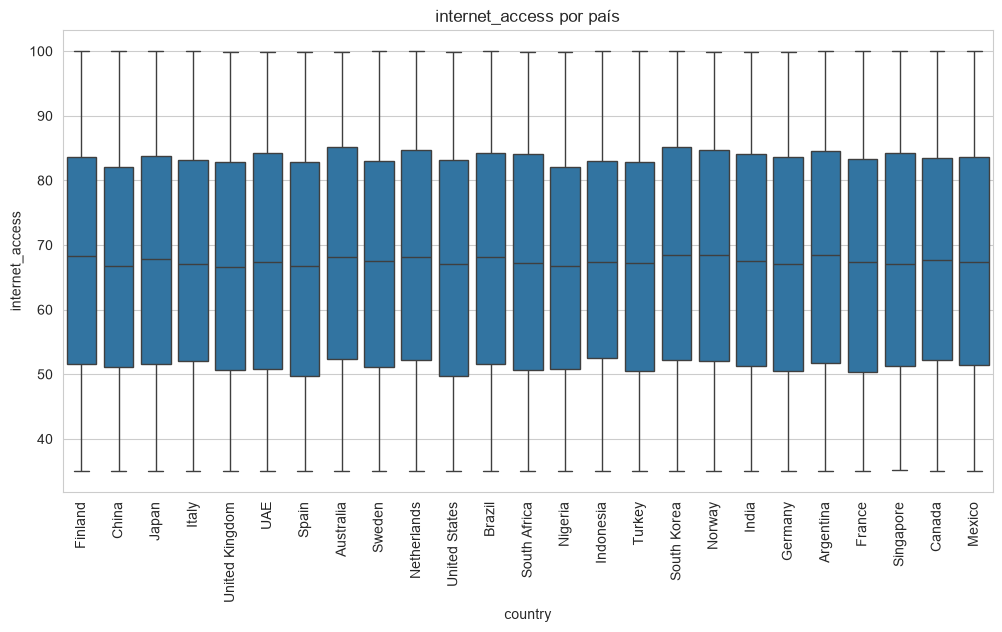

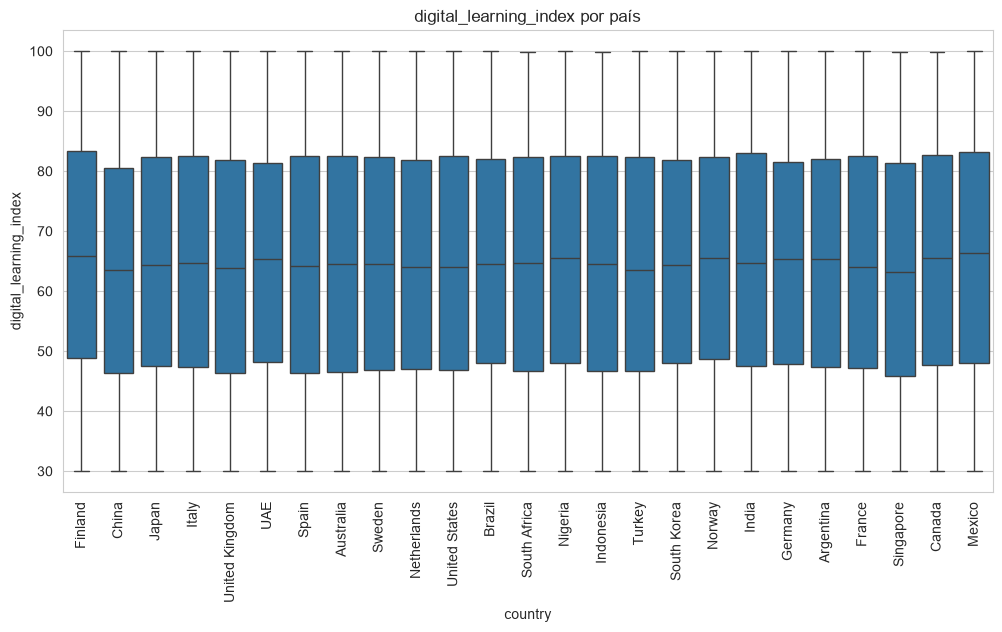

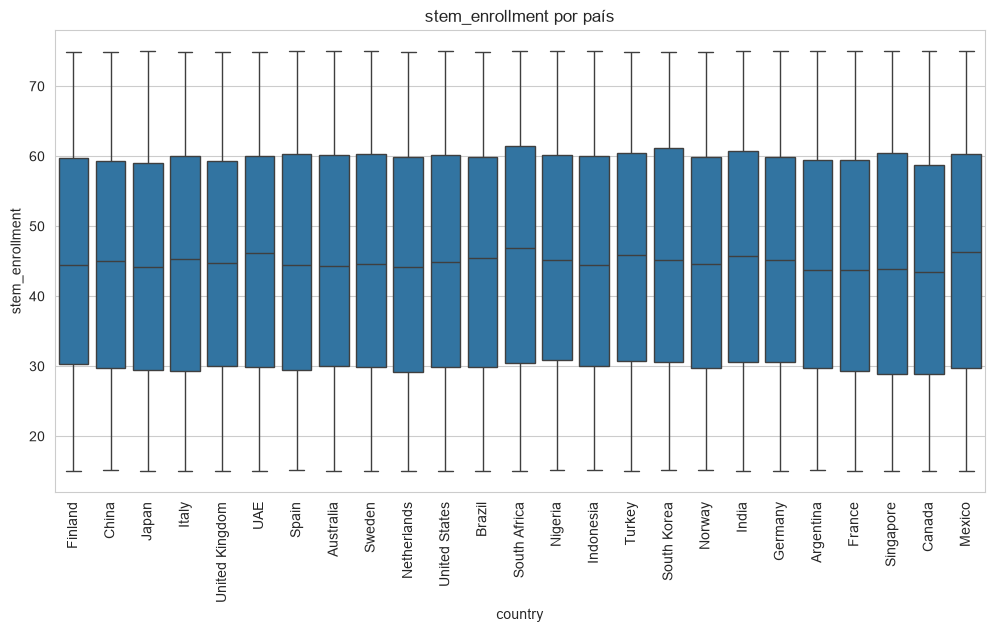

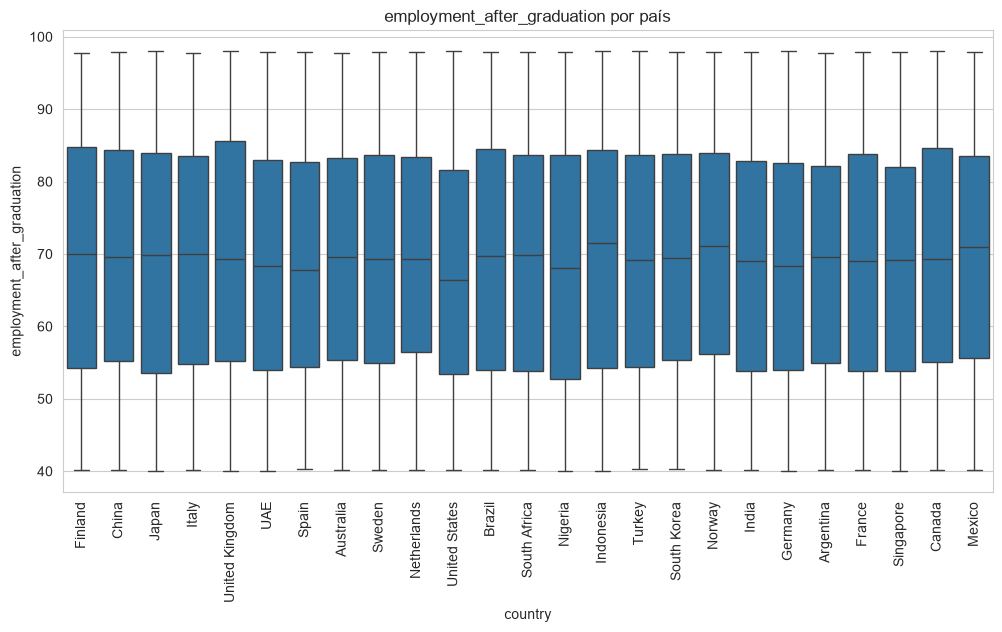

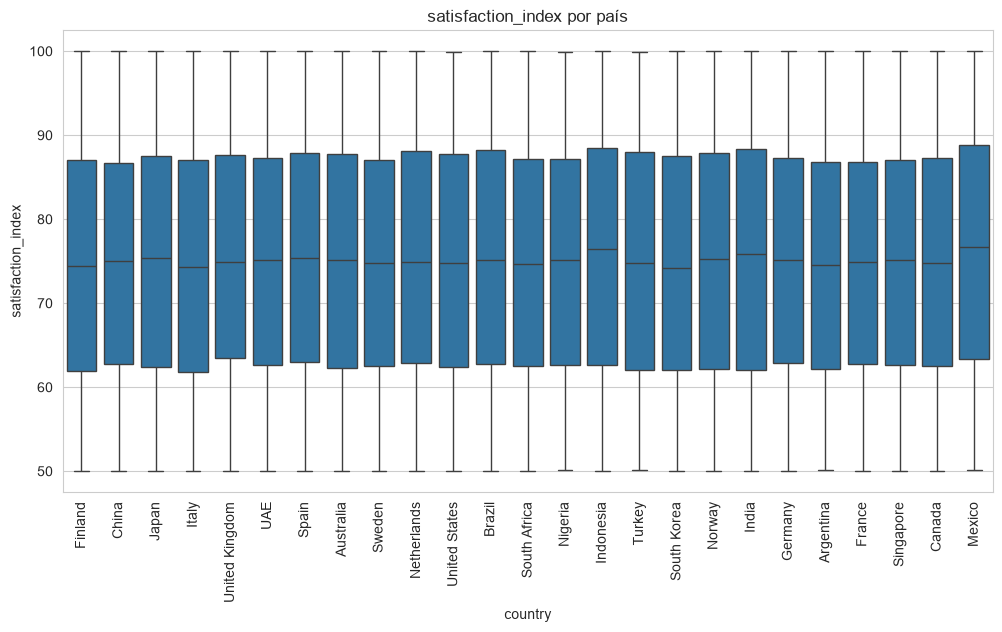

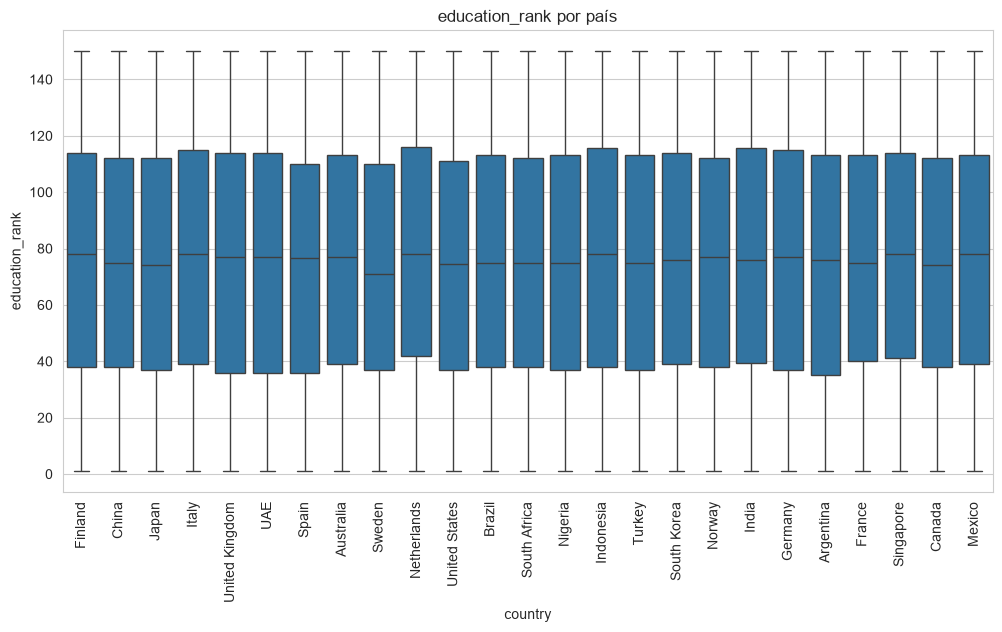

In [76]:
## Por pais
for col in numeric_cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_world_clean, x="country", y=col)
    plt.title(f"{col} por país")
    plt.xticks(rotation=90)
    plt.show()

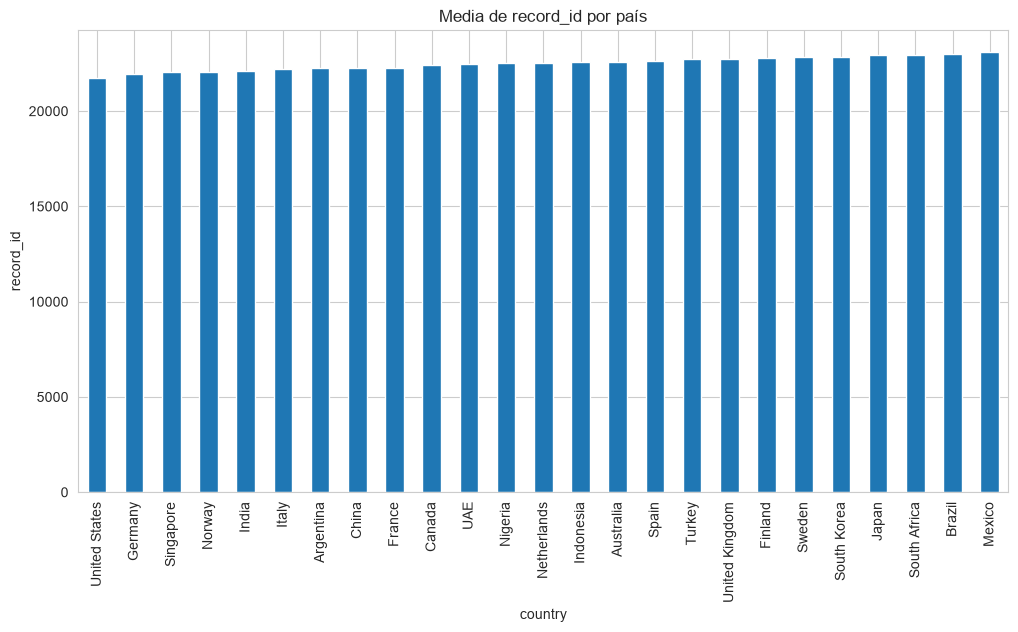

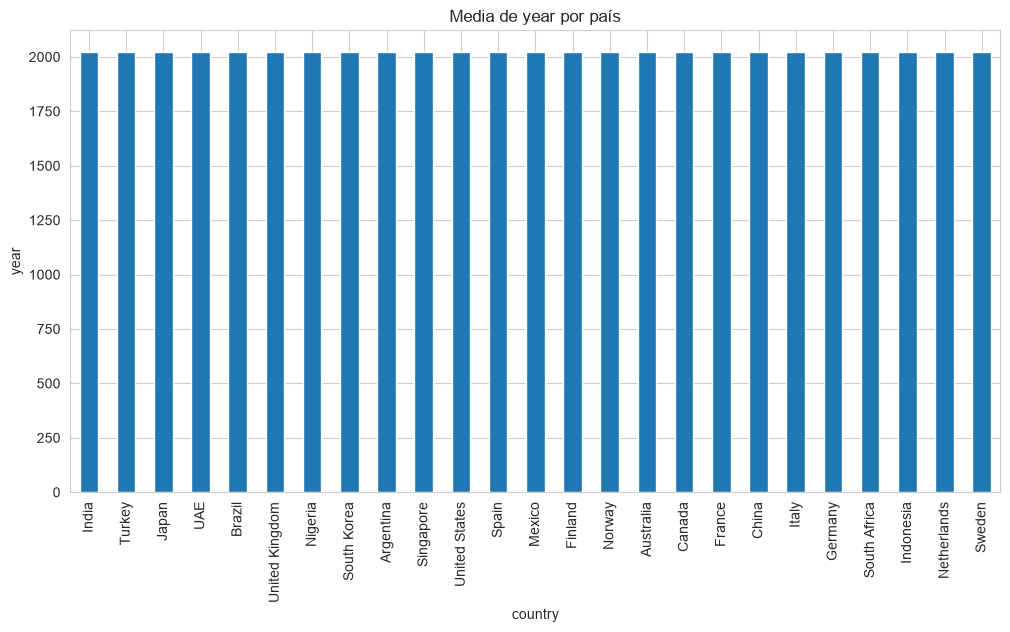

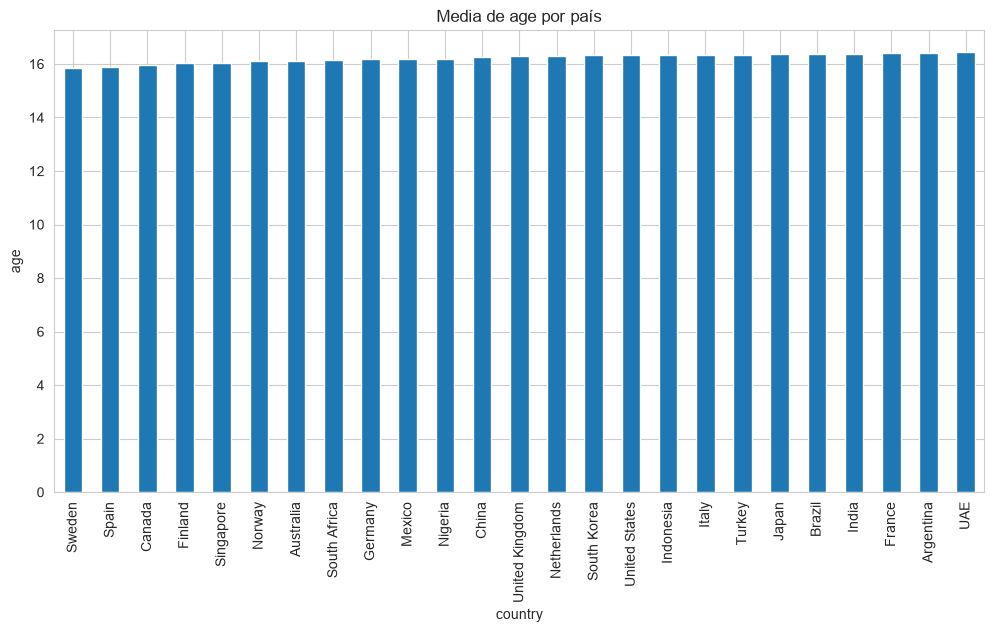

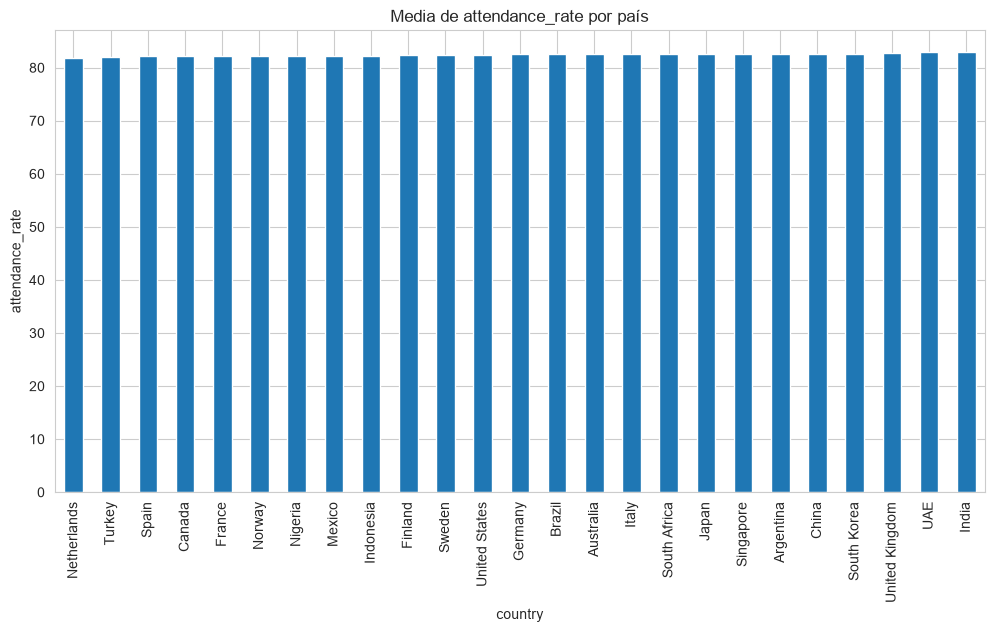

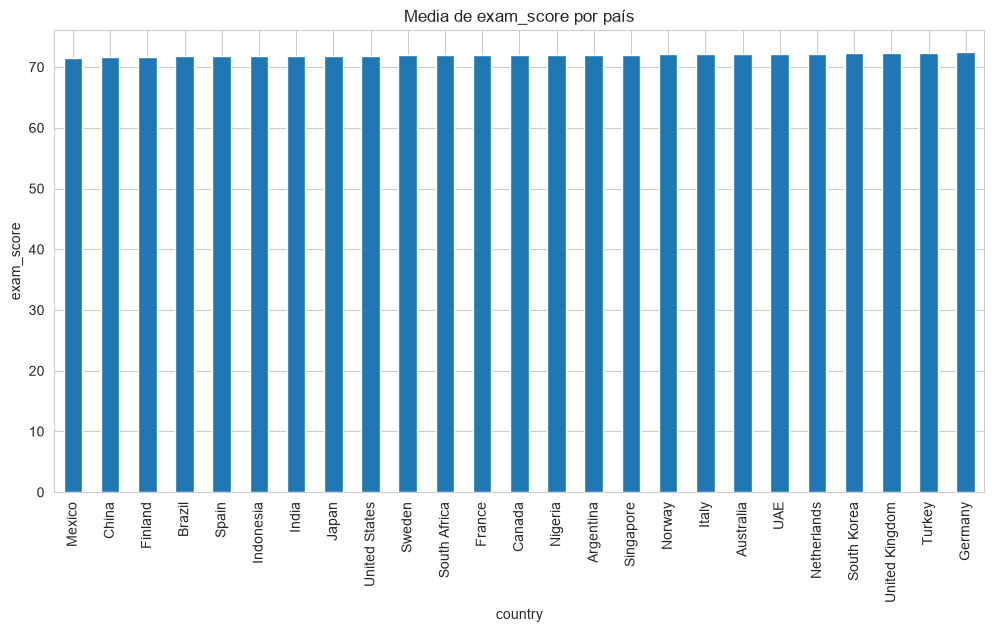

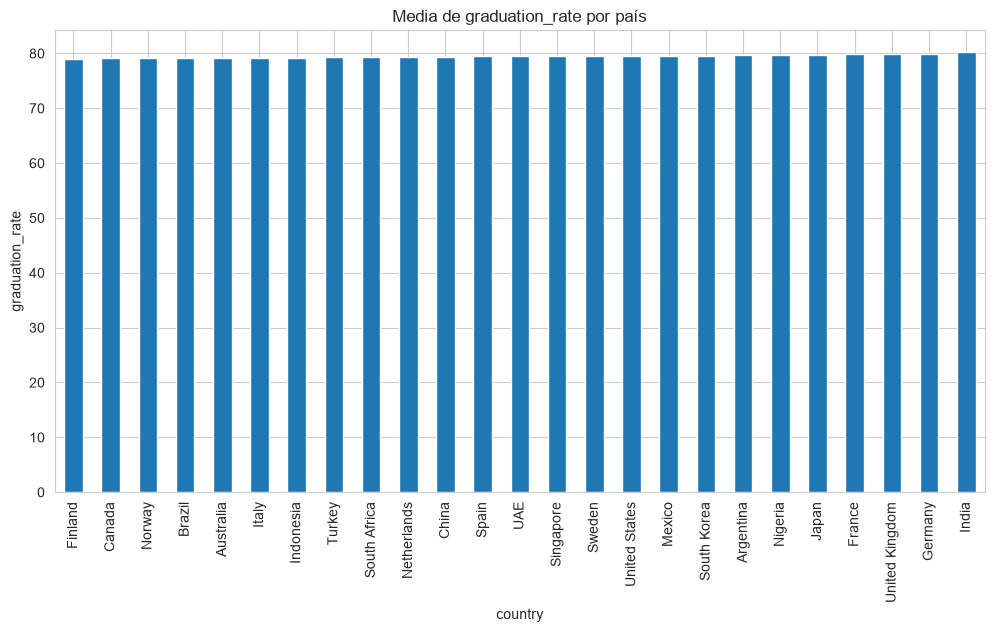

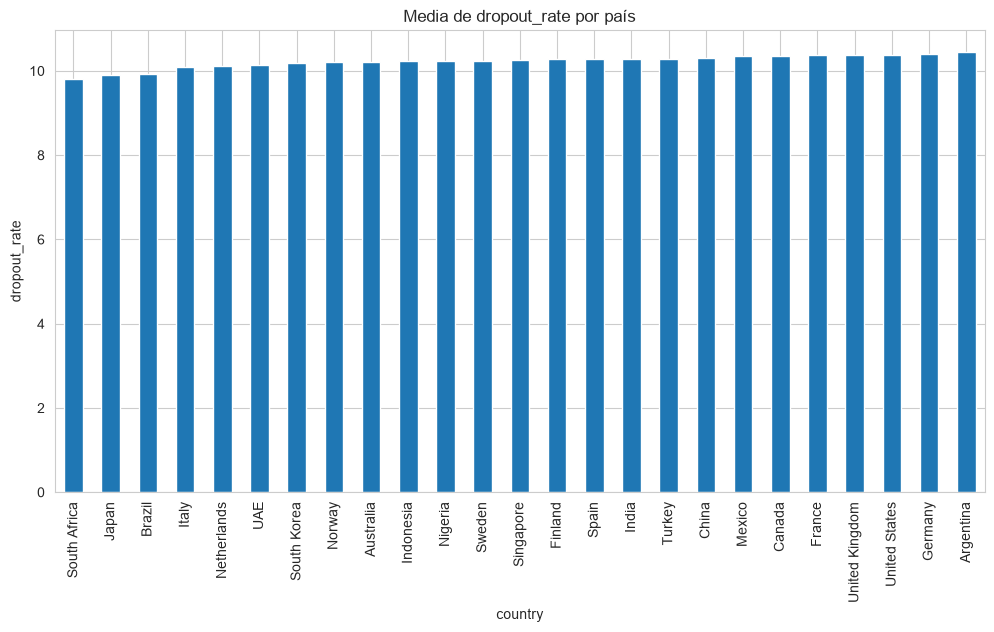

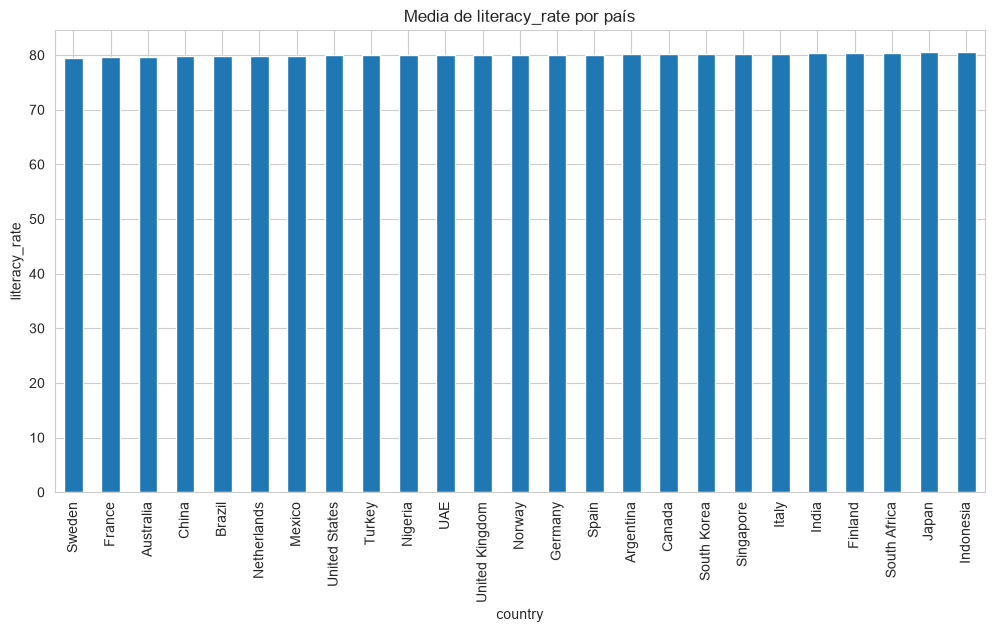

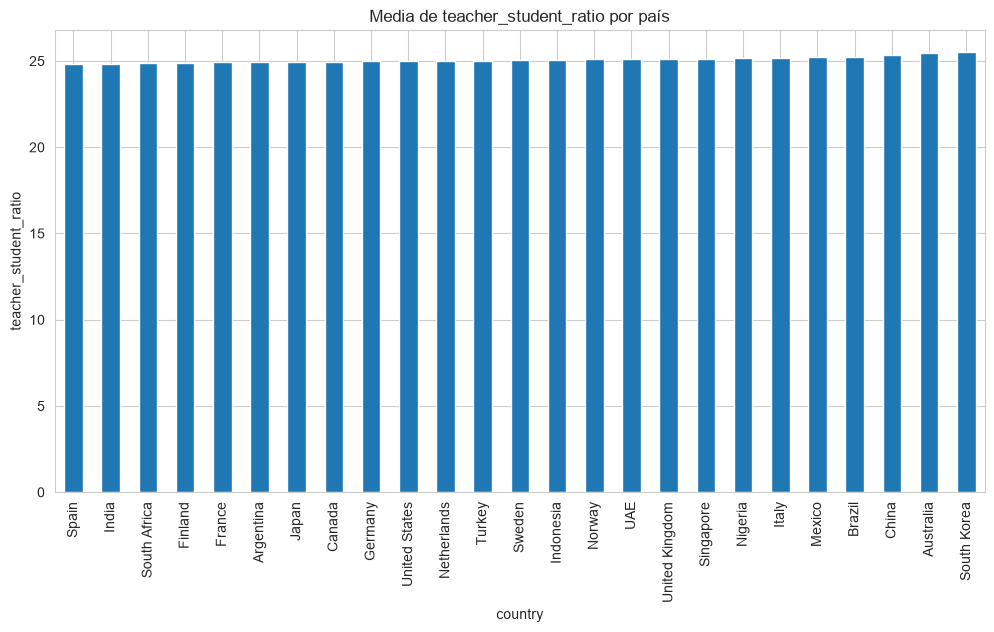

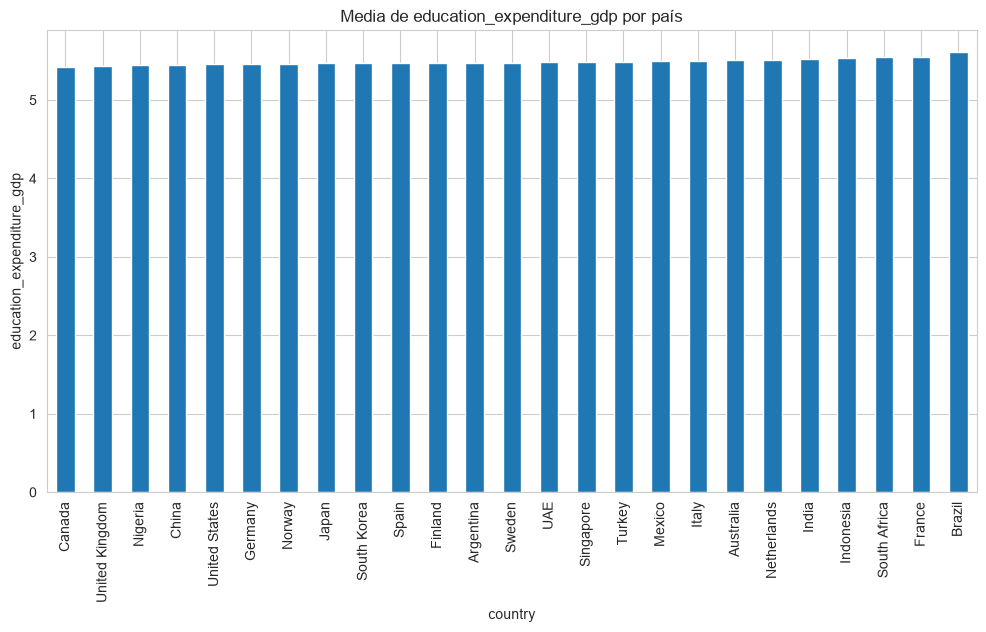

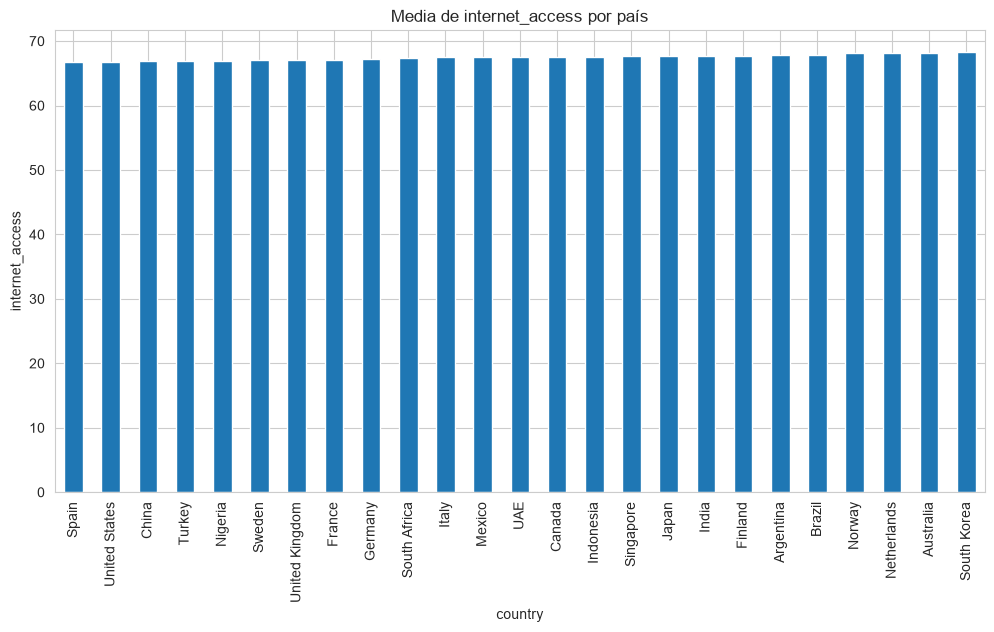

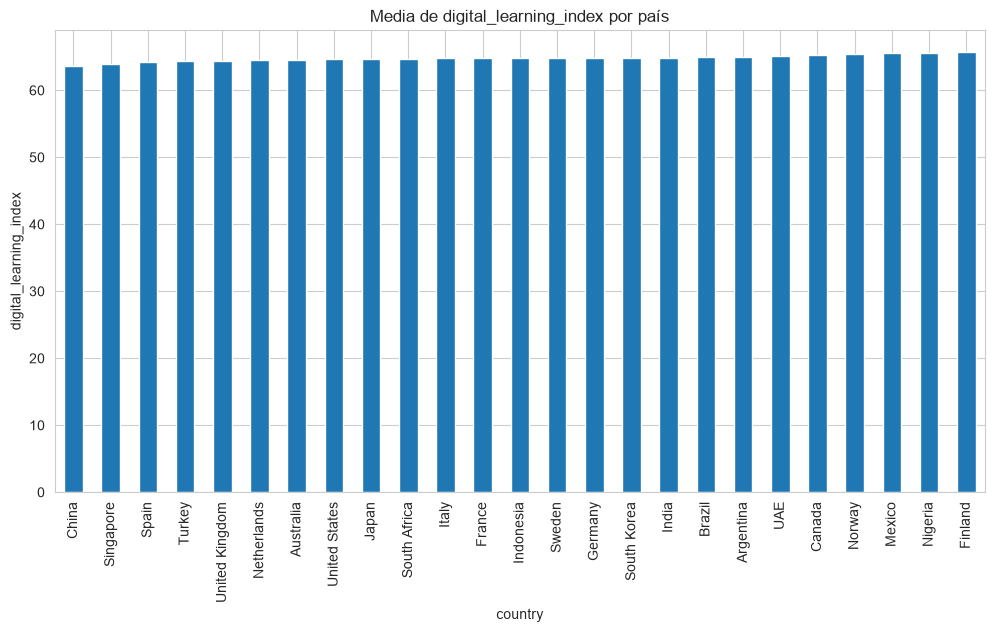

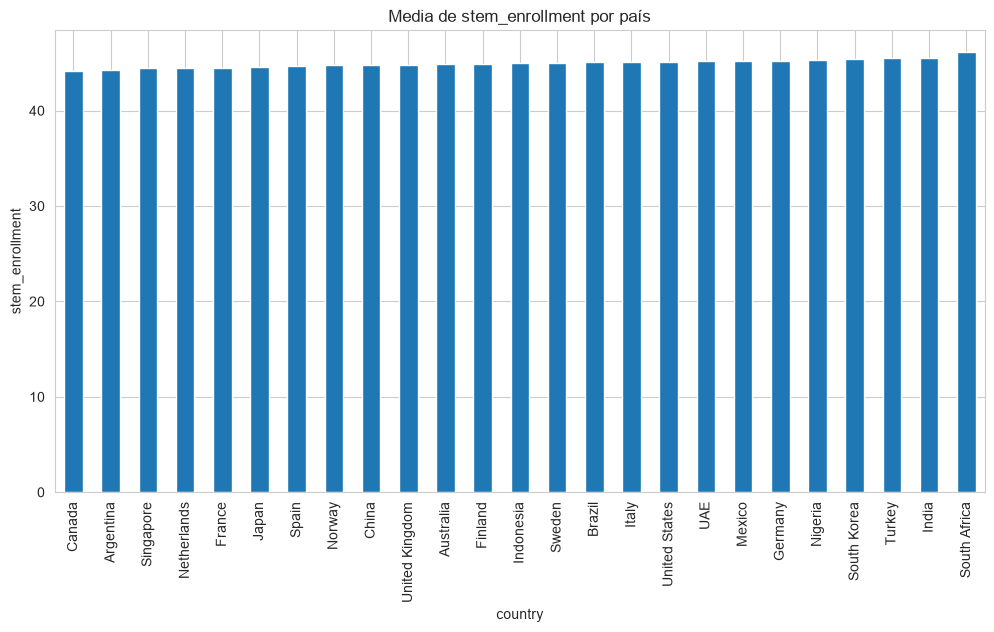

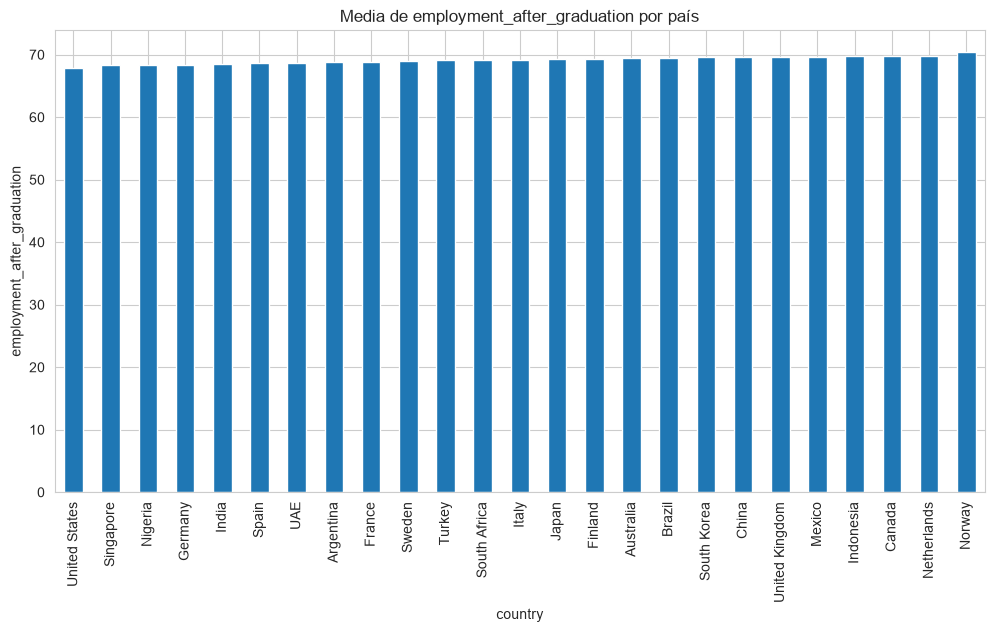

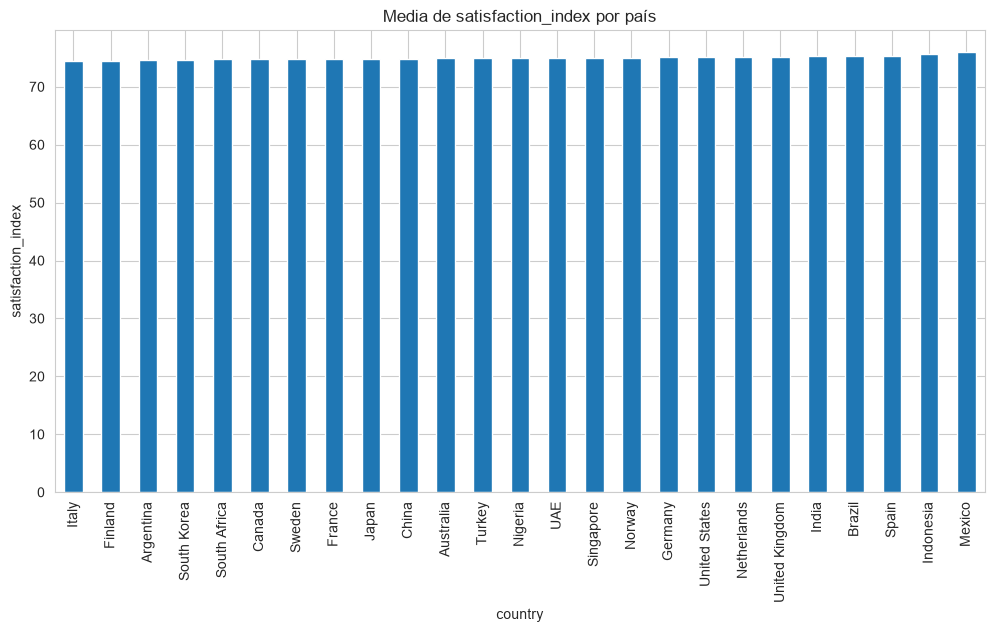

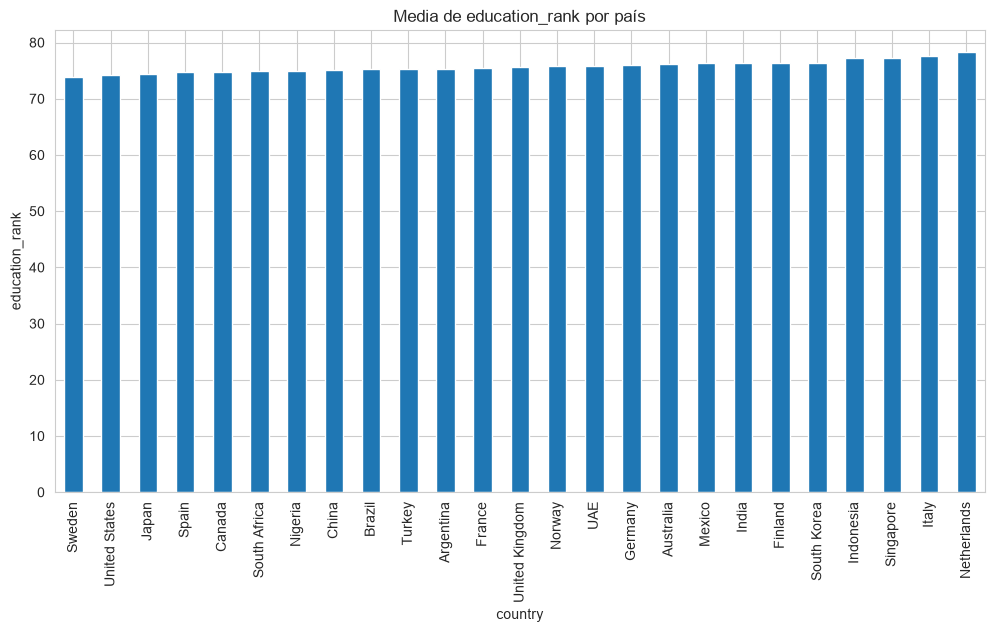

In [77]:
## Medias por pais
for col in numeric_cols:
    plt.figure(figsize=(12, 6))
    df_world_clean.groupby("country")[col].mean().sort_values().plot(kind="bar")
    plt.title(f"Media de {col} por país")
    plt.xticks(rotation=90)
    plt.ylabel(col)
    plt.show()

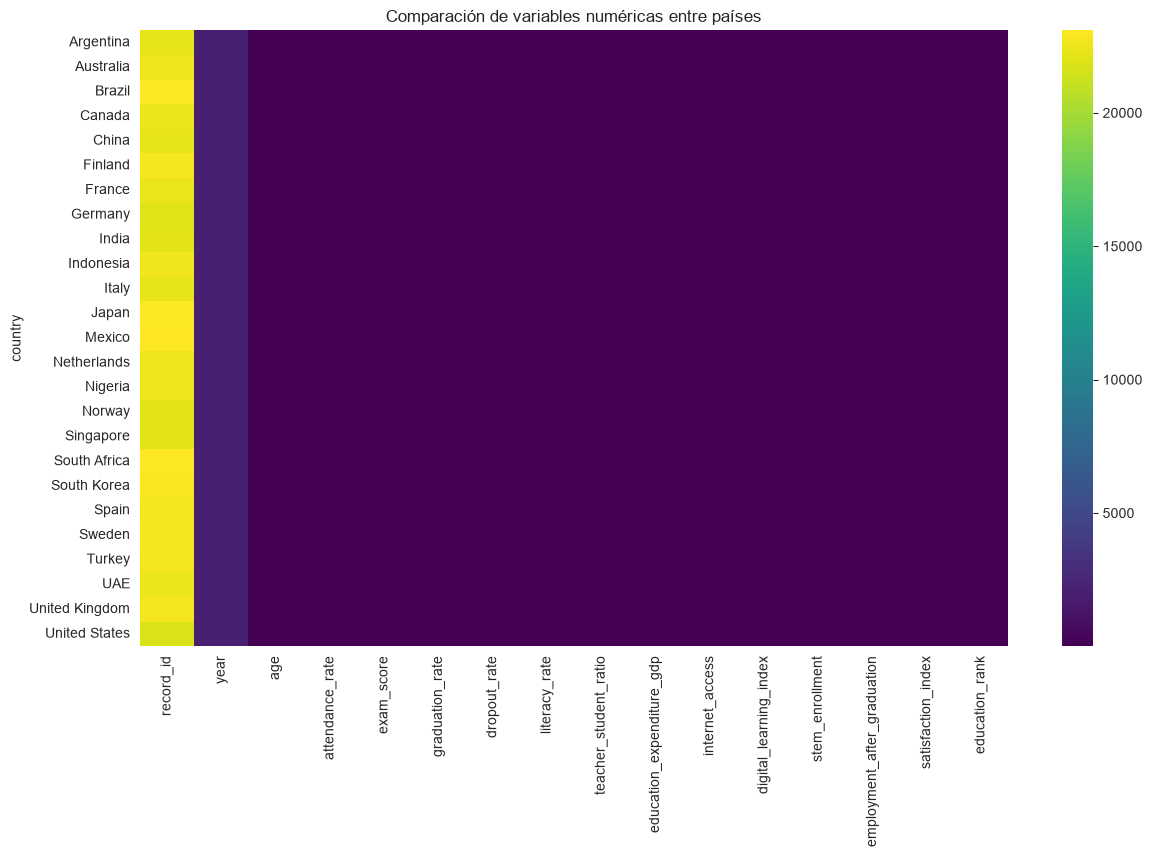

In [78]:
pivot = df_world_clean.groupby("country")[numeric_cols].mean()

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, cmap="viridis")
plt.title("Comparación de variables numéricas entre países")
plt.show()

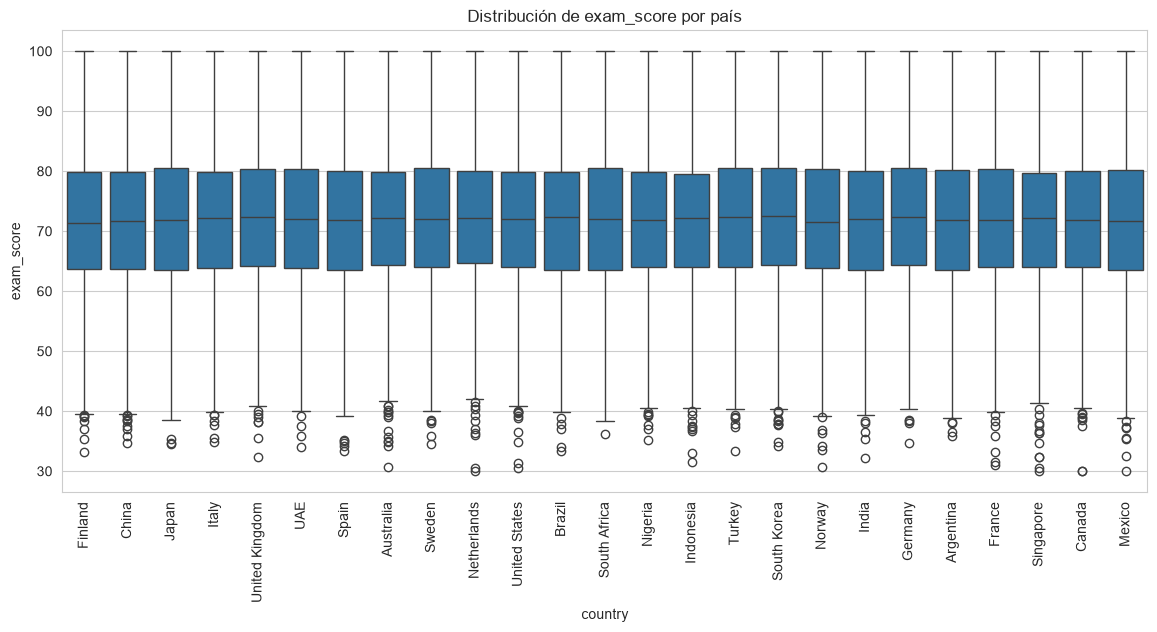

In [80]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_world_clean, x="country", y="exam_score")
plt.xticks(rotation=90)
plt.title("Distribución de exam_score por país")
plt.show()

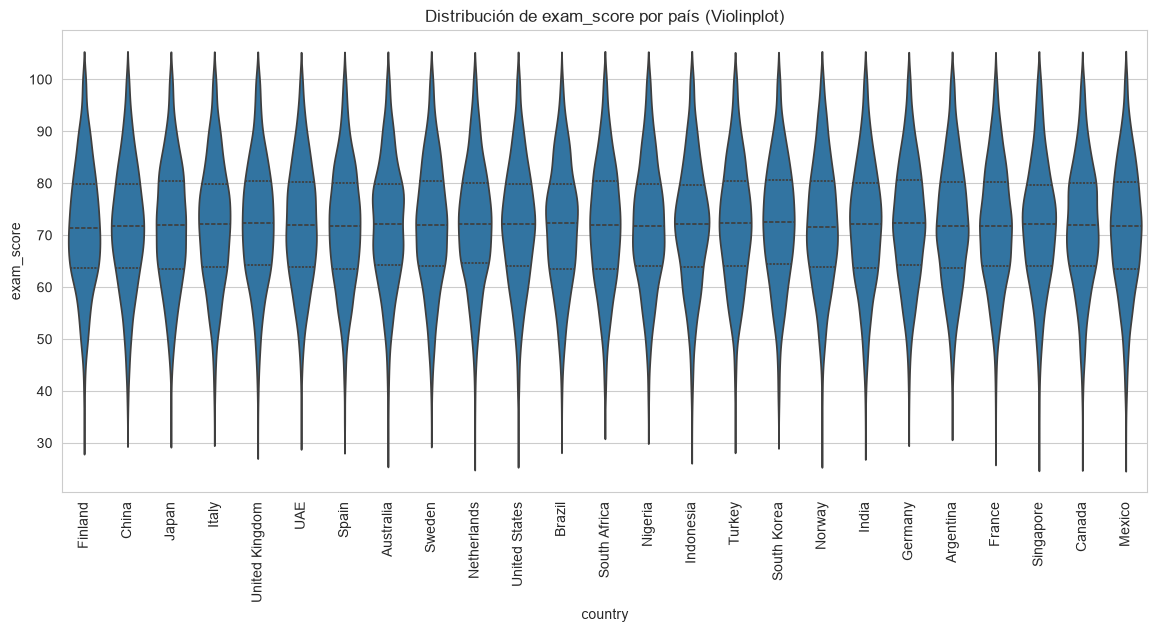

In [81]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=df_world_clean, x="country", y="exam_score", inner="quartile")
plt.xticks(rotation=90)
plt.title("Distribución de exam_score por país (Violinplot)")
plt.show()

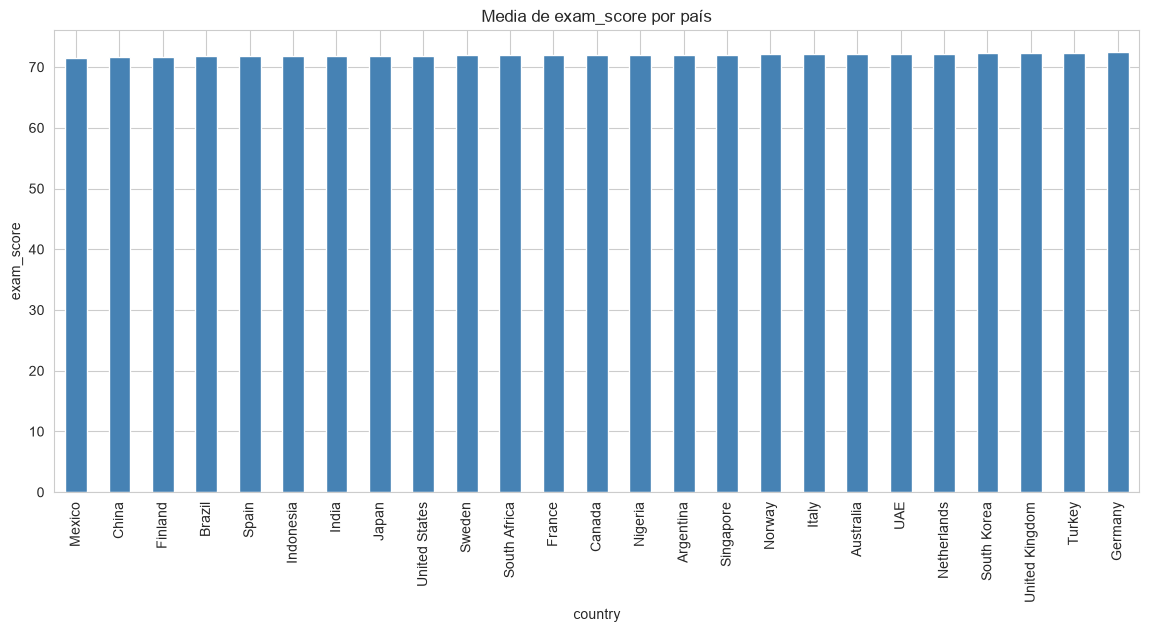

In [82]:
df_world_clean.groupby("country")["exam_score"].mean().sort_values().plot(
    kind="bar", figsize=(14, 6), color="steelblue"
)
plt.title("Media de exam_score por país")
plt.ylabel("exam_score")
plt.xticks(rotation=90)
plt.show()

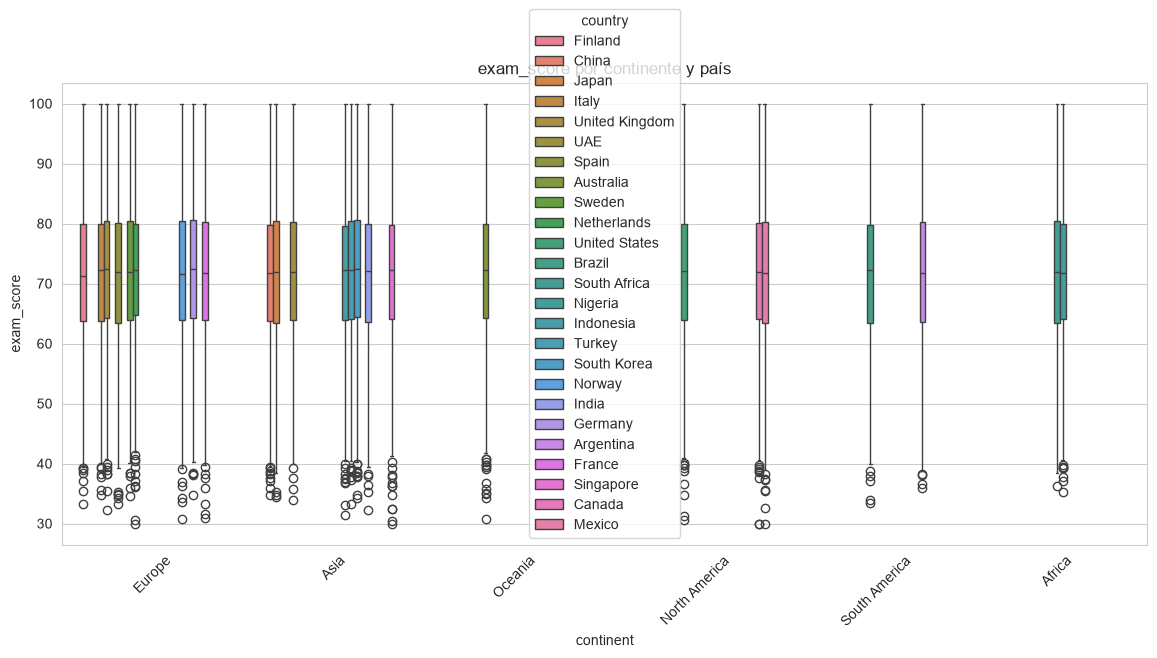

In [83]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_world_clean, x="continent", y="exam_score", hue="country")
plt.xticks(rotation=45)
plt.title("exam_score por continente y país")
plt.show()

Proyecto: Análisis Exploratorio del Sistema Educativo Internacional
Este proyecto realiza un Análisis Exploratorio de Datos (EDA) sobre un dataset internacional que combina información académica, digitalización educativa, asistencia, abandono escolar y rendimiento académico. El objetivo es identificar patrones, diferencias entre países y métricas clave que permitan comprender el estado global de la educación.
📁 Contenido del proyecto
El proyecto incluye:
•	Limpieza y preparación de datos
•	Unión de datasets educativos
•	Tratamiento de nulos y tipos de datos
•	Detección de outliers mediante IQR
•	Análisis descriptivo de variables
•	Comparación entre países
•	Visualizaciones (boxplots, violinplots, barplots, heatmaps)
•	Dashboard profesional en Excel
•	Conclusiones del EDA
📂 Estructura del repositorio
Código
📦 Proyecto_EDA_Educacion
 ┣ 📂 data
 ┃ ┣ student-mat.csv
 ┃ ┗ world_education.csv
 ┣ 📂 notebooks
 ┃ ┗ EDA_educacion.ipynb
 ┣ 📂 dashboard
 ┃ ┗ Dashboard_Educacion.xlsx
 ┣ 📜 README.md
 ┗ 📜 requirements.txt
🛠️ Tecnologías utilizadas
•	Python 3.10
•	Pandas
•	NumPy
•	Matplotlib
•	Seaborn
•	Jupyter Notebook
•	Excel (dashboard final)
🔧 Preparación del entorno
Instala las dependencias:
bash
pip install -r requirements.txt
O manualmente:
bash
pip install pandas numpy matplotlib seaborn openpyxl xlsxwriter
📊 Descripción del dataset
El dataset final combina:
1. student-mat.csv
•	Datos de estudiantes
•	Variables académicas y personales
•	395 registros
•	33 columnas
2. world_education.csv
•	Indicadores educativos globales
•	Digitalización
•	Abandono escolar
•	Ratio profesor/alumno
•	45.000+ registros
•	26 columnas
🧹 Limpieza y preparación
Se realizaron las siguientes tareas:
•	Carga correcta del CSV con separador ;
•	Conversión de columnas numéricas
•	Eliminación de duplicados
•	Tratamiento de nulos
•	Unión de datasets
•	Normalización de tipos de datos
•	Conversión segura con pd.to_numeric(errors="coerce")
📈 Análisis Exploratorio (EDA)
🔹 Estadísticos descriptivos
•	Medias, medianas, desviaciones
•	Distribuciones por variable
•	Identificación de valores extremos
🔹 Outliers (IQR)
Se detectaron outliers en:
•	exam_score
•	dropout_rate
•	teacher_student_ratio
Los outliers se conservaron porque aportan información relevante.
🔹 Comparación entre países
Se analizaron diferencias en:
•	Rendimiento académico
•	Asistencia
•	Graduación
•	Abandono escolar
•	Acceso a internet
•	Digitalización educativa
🔹 Visualizaciones generadas
•	Boxplots por variable
•	Violinplots
•	Barras por país
•	Heatmaps
•	Líneas comparativas
📊 Dashboard en Excel
Se creó un dashboard profesional con:
⭐ KPIs principales
•	Exam Score medio
•	Attendance Rate medio
•	Graduation Rate medio
•	Dropout Rate medio
📊 Gráficos
•	Exam Score por país
•	Attendance Rate por país
•	Graduation Rate por país
•	Internet Access por país
•	Dropout Rate por país
•	Teacher-Student Ratio
🎨 Diseño
•	Colores neutros
•	Tarjetas KPI
•	Gráficos ordenados por zonas
🧠 Conclusiones del EDA
•	El rendimiento académico varía significativamente entre países.
•	La digitalización educativa es un factor clave en los resultados.
•	La tasa de abandono escolar es un indicador crítico.
•	La relación profesor/alumno influye en el rendimiento.
•	Los países con mayor acceso digital muestran mejores métricas educativas.
📌 Limitaciones
•	Algunos datasets contienen nulos estructurales.
•	La unión de datasets requiere limpieza previa para evitar mezclas de tipos.
